# bias_std_turn_5d 因子

该因子衡量股票最近5个交易日的换手率波动，相对于过去2年换手率波动水平的偏离程度。

$$
\text{bias\_std\_turn\_5d}_{i,t}
=
\frac{
\operatorname{Std}\left(\text{Turnover}_{i,t-4:t}\right)
}{
\operatorname{Std}\left(\text{Turnover}_{i,t-L+1:t}\right)
}
-1
$$

其中：

- $i$：股票；
- $t$：因子计算日；
- $\text{Turnover}_{i,t}$：股票 $i$ 在交易日 $t$ 的日换手率；
- $L$：过去2年对应的交易日数量，通常取约504个交易日；
- 分子：最近5个有效交易日换手率的标准差；
- 分母：最近2年有效日换手率的标准差。

数据处理规则

1. 换手率为0的日期不参与标准差计算。
2. 停牌日期不作为有效观察值。
3. 分母为0或有效样本不足时，将因子值设置为缺失。
4. 因子计算只能使用截至交易日 $t$ 收盘已经获得的数据。
5. 在 $t$ 日收盘后形成信号，最早于 $t+1$ 交易日开盘交易。

因子方向

该因子与未来收益呈负相关，即因子值越低，股票未来预期收益越高。

## 原始因子基础指标计算

[1/5] 查询 BigQuant 每 20 个交易日截面：2022-01-01 至 2026-06-30，滚动窗口=5/504个交易日
      返回 288,109 行、55 个截面，耗时 13.7 秒
[2/5] 构造相邻 20 交易日截面的收益标签，并过滤基础股票池
      有效样本 202,894 行，信号期 2022-01-04 至 2026-05-26
[3/5] 逐月计算基础指标 | IC暴露=neutralized | 最小截面=80
      已完成 12/54 个截面
      已完成 24/54 个截面
      已完成 36/54 个截面
      已完成 48/54 个截面
      已完成 54/54 个截面
      得到 54 个有效截面，耗时 18.5 秒
[4/5] 汇总基础指标


,因子名称,因子含义,IC口径,截面周期,收益周期,有效截面数,平均样本数,IC均值,RankIC均值,ICIR,RankICIR,因子收益率均值,t均值
0,bias_std_turn_5d,5日换手率标准差 / 两年换手率标准差 - 1（原始方向，低值优）,行业、市值中性化,每20个交易日,本次截面至下一次截面（20个交易日）,54,3757,-4.23%,-6.84%,-0.642,-1.068,-0.35%,-2.378


[5/5] 绘制每 20 交易日 IC / RankIC 时序图


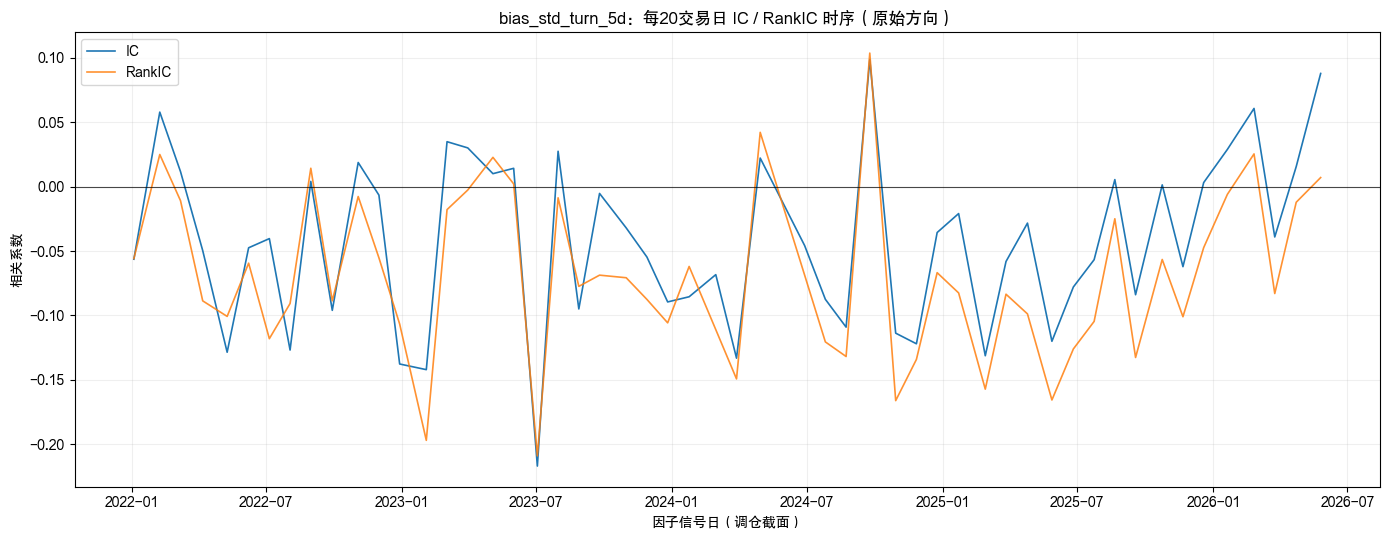

完成。factor_return 为每20个交易日的小数收益单位；原始因子低值优时，IC、RankIC、因子收益率出现负值是方向含义，不是计算错误。


In [1]:
"""
BigQuant：原始 bias_std_turn_5d 因子基础指标测试

因子定义
--------
bias_std_turn_5d = std(turn, 5个交易日) / std(turn, 504个交易日) - 1

计算滚动标准差时剔除 turn <= 0 的观测。因子保持研报中的原始方向，不乘 -1；
因此若“低值优”在样本期成立，IC、RankIC 和因子收益率通常应为负。

评价口径
--------
1. 从 START_DATE 起，每隔 N 个交易日形成一次因子暴露；
2. 标签为本次调仓日收盘到下一次调仓日收盘的收益率；
3. 因子先做截面 MAD 去极值和标准化；
4. 默认将因子对 log(总市值) 和行业哑变量回归，使用残差计算 IC/RankIC；
5. 因子收益率使用横截面 WLS：下一月收益 ~ 因子 + log(总市值) + 行业；
   权重为 sqrt(流通市值)，报告回归中因子系数及其 t 值；
6. ICIR、RankICIR 均为均值 / 时间序列样本标准差，不做年化。

代码只输出研究结果，不自动保存运行结果到磁盘。
"""

import time
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd

from bigquant import dai


# =========================
# 可修改参数
# =========================
START_DATE = "2022-01-01"
END_DATE = "2026-06-30"

# 截面/调仓周期。20 表示从区间内首个交易日起，每 20 个交易日取一个截面。
REBALANCE_EVERY_N_TRADING_DAYS = 20

SHORT_WINDOW = 5
LONG_WINDOW = 504              # 约两个交易年
QUERY_LOOKBACK_DAYS = 850      # 给 504 日滚动窗口预留充足自然日
MIN_LIST_DAYS = 730            # 避免长期标准差被极短上市历史主导

MAD_MULTIPLIER = 5.0
MIN_CROSS_SECTION = 80

# "neutralized"：与研报更接近，IC 使用行业、市值中性化后的因子暴露
# "raw"：IC 使用仅经 MAD 去极值、标准化的原始因子暴露
IC_EXPOSURE_MODE = "neutralized"

# 研报因子收益率回归使用 sqrt(流通市值) 权重；设为 False 可切换为 OLS
USE_WLS_FOR_FACTOR_RETURN = True
PROGRESS_EVERY = 12


FACTOR_NAME = "bias_std_turn_5d"
FACTOR_DESCRIPTION = "5日换手率标准差 / 两年换手率标准差 - 1（原始方向，低值优）"


def _validate_parameters() -> None:
    if SHORT_WINDOW < 2:
        raise ValueError("SHORT_WINDOW 必须至少为 2")
    if LONG_WINDOW <= SHORT_WINDOW:
        raise ValueError("LONG_WINDOW 必须大于 SHORT_WINDOW")
    if MIN_CROSS_SECTION < 10:
        raise ValueError("MIN_CROSS_SECTION 不应小于 10")
    if not isinstance(REBALANCE_EVERY_N_TRADING_DAYS, int):
        raise TypeError("REBALANCE_EVERY_N_TRADING_DAYS 必须是整数")
    if REBALANCE_EVERY_N_TRADING_DAYS < 1:
        raise ValueError("REBALANCE_EVERY_N_TRADING_DAYS 必须至少为 1")
    if IC_EXPOSURE_MODE not in {"raw", "neutralized"}:
        raise ValueError("IC_EXPOSURE_MODE 只能为 'raw' 或 'neutralized'")


def _date_with_offset(date: str, days: int) -> str:
    return (pd.Timestamp(date) + pd.Timedelta(days=days)).strftime("%Y-%m-%d")


def query_rebalance_panel() -> pd.DataFrame:
    """查询每 N 个交易日的截面，并在数据库端计算滚动换手率标准差。"""
    query_start = _date_with_offset(START_DATE, -QUERY_LOOKBACK_DAYS)
    # 查询范围须覆盖 END_DATE 后至少一个完整 N 日周期，供最后一期生成标签。
    label_buffer_days = max(45, 2 * REBALANCE_EVERY_N_TRADING_DAYS + 20)
    query_end = _date_with_offset(END_DATE, label_buffer_days)

    sql = f"""
    WITH trading_dates AS (
        SELECT DISTINCT date
        FROM cn_stock_prefactors
        WHERE date >= '{START_DATE}'
          AND date <= '{query_end}'
    ),
    numbered_trading_dates AS (
        SELECT
            date,
            row_number() OVER (ORDER BY date) AS trading_day_number
        FROM trading_dates
    ),
    selected_dates AS (
        SELECT
            date,
            row_number() OVER (ORDER BY date) AS rebalance_index
        FROM numbered_trading_dates
        WHERE mod(trading_day_number - 1, {REBALANCE_EVERY_N_TRADING_DAYS}) = 0
    ),
    daily_factor AS (
        SELECT
            date,
            instrument,
            close,
            total_market_cap,
            float_market_cap,
            sw2014_level1 AS industry,
            st_status,
            suspended,
            list_days,
            m_stddev(if(turn > 0, turn, NULL), {SHORT_WINDOW}) AS turn_std_short,
            m_stddev(if(turn > 0, turn, NULL), {LONG_WINDOW}) AS turn_std_long
        FROM cn_stock_prefactors
    )
    SELECT
        f.date,
        d.rebalance_index,
        f.instrument,
        f.close,
        f.total_market_cap,
        f.float_market_cap,
        f.industry,
        f.st_status,
        f.suspended,
        f.list_days,
        f.turn_std_short,
        f.turn_std_long,
        f.turn_std_short / nullif(f.turn_std_long, 0) - 1 AS {FACTOR_NAME}
    FROM daily_factor f
    INNER JOIN selected_dates d
        ON f.date = d.date
    ORDER BY f.date, f.instrument
    """

    print(
        f"[1/5] 查询 BigQuant 每 {REBALANCE_EVERY_N_TRADING_DAYS} 个交易日截面："
        f"{START_DATE} 至 {END_DATE}，滚动窗口={SHORT_WINDOW}/{LONG_WINDOW}个交易日"
    )
    started = time.time()
    result = dai.query(
        sql,
        filters={"date": [query_start, query_end]},
    ).df()
    if result is None or result.empty:
        raise ValueError(
            "BigQuant 查询结果为空。请检查日期范围、数据权限以及 "
            "cn_stock_prefactors 中 turn/sw2014_level1 等字段是否可用。"
        )

    result["date"] = pd.to_datetime(result["date"])
    print(
        f"      返回 {len(result):,} 行、{result['date'].nunique():,} 个截面，"
        f"耗时 {time.time() - started:.1f} 秒"
    )
    return result


def add_next_rebalance_return(panel: pd.DataFrame) -> pd.DataFrame:
    """添加下一调仓日收益，并严格排除股票缺失导致的跨期标签。"""
    data = panel.copy()
    data = data.sort_values(["instrument", "date"])

    by_stock = data.groupby("instrument", sort=False)
    data["return_end_date"] = by_stock["date"].shift(-1)
    data["next_rebalance_close"] = by_stock["close"].shift(-1)
    data["next_rebalance_index"] = by_stock["rebalance_index"].shift(-1)

    # 股票若在紧邻的下一调仓截面缺失，不能把更远一期误作 N 日标签。
    is_exact_next_period = data["next_rebalance_index"] == data["rebalance_index"] + 1

    data["forward_return"] = np.where(
        is_exact_next_period,
        data["next_rebalance_close"] / data["close"] - 1.0,
        np.nan,
    )

    signal_start = pd.Timestamp(START_DATE)
    signal_end = pd.Timestamp(END_DATE)
    data = data.loc[data["date"].between(signal_start, signal_end)].copy()

    # 最后一个无法取得完整下一调仓日收益的截面会在此自然剔除。
    data = data.loc[data["forward_return"].notna()].copy()
    return data


def mad_winsorize_and_zscore(values: pd.Series) -> pd.Series:
    """截面中位数/MAD去极值后标准化；不改变因子方向。"""
    x = pd.to_numeric(values, errors="coerce").astype(float)
    valid = np.isfinite(x)
    result = pd.Series(np.nan, index=x.index, dtype=float)
    if valid.sum() < 3:
        return result

    xv = x.loc[valid]
    median = xv.median()
    mad = (xv - median).abs().median()

    if np.isfinite(mad) and mad > 0:
        lower = median - MAD_MULTIPLIER * mad
        upper = median + MAD_MULTIPLIER * mad
        xv = xv.clip(lower, upper)

    std = xv.std(ddof=1)
    if not np.isfinite(std) or std <= 0:
        return result
    result.loc[valid] = (xv - xv.mean()) / std
    return result


def _industry_design(industry: pd.Series) -> pd.DataFrame:
    values = industry.fillna("UNKNOWN").astype(str)
    return pd.get_dummies(values, prefix="industry", drop_first=True, dtype=float)


def neutralize_factor(
    factor_z: pd.Series,
    log_market_cap: pd.Series,
    industry: pd.Series,
) -> pd.Series:
    """用 OLS 剔除 log(总市值) 和行业对因子暴露的线性影响。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(factor_z, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)

    residual = pd.Series(np.nan, index=factor_z.index, dtype=float)
    if valid.sum() <= design.shape[1] + 2:
        return residual

    x_array = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x_array, y_array, rcond=None)[0]
    residual.loc[valid] = y_array - x_array @ beta
    return mad_winsorize_and_zscore(residual)


def weighted_factor_regression(
    returns: pd.Series,
    factor_z: pd.Series,
    log_market_cap: pd.Series,
    industry: pd.Series,
    float_market_cap: pd.Series,
) -> Tuple[float, float]:
    """截面回归并返回因子系数和带符号 t 值。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "factor": pd.to_numeric(factor_z, errors="coerce"),
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(returns, errors="coerce")
    cap = pd.to_numeric(float_market_cap, errors="coerce")

    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)
    if USE_WLS_FOR_FACTOR_RETURN:
        valid &= np.isfinite(cap) & (cap > 0)

    x = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    n_obs, n_params = x.shape
    if n_obs <= n_params + 2:
        return np.nan, np.nan

    if USE_WLS_FOR_FACTOR_RETURN:
        # 回归目标权重为 sqrt(流通市值)。WLS变换需要再取一次平方根。
        regression_weight = np.sqrt(cap.loc[valid].to_numpy(dtype=float))
        root_weight = np.sqrt(regression_weight)
        x_fit = x * root_weight[:, None]
        y_fit = y_array * root_weight
    else:
        x_fit = x
        y_fit = y_array

    xtx_inv = np.linalg.pinv(x_fit.T @ x_fit)
    beta = xtx_inv @ x_fit.T @ y_fit
    residual = y_fit - x_fit @ beta
    degrees_of_freedom = n_obs - n_params
    residual_variance = float(residual @ residual) / degrees_of_freedom
    covariance = residual_variance * xtx_inv

    factor_beta = float(beta[1])
    factor_se = float(np.sqrt(max(covariance[1, 1], 0.0)))
    factor_t = factor_beta / factor_se if factor_se > 0 else np.nan
    return factor_beta, factor_t


def calculate_cross_section_metrics(section: pd.DataFrame) -> Optional[Dict]:
    """计算单个调仓截面的 IC、RankIC、因子收益率和 t 值。"""
    required = [
        FACTOR_NAME,
        "forward_return",
        "total_market_cap",
        "float_market_cap",
        "industry",
    ]
    sample = section.dropna(subset=required).copy()
    sample = sample.loc[
        np.isfinite(sample[FACTOR_NAME])
        & np.isfinite(sample["forward_return"])
        & (sample["total_market_cap"] > 0)
        & (sample["float_market_cap"] > 0)
    ].copy()
    if len(sample) < MIN_CROSS_SECTION:
        return None

    sample["factor_z"] = mad_winsorize_and_zscore(sample[FACTOR_NAME])
    sample["log_market_cap"] = np.log(sample["total_market_cap"].astype(float))
    sample = sample.dropna(subset=["factor_z", "log_market_cap"])
    if len(sample) < MIN_CROSS_SECTION:
        return None

    if IC_EXPOSURE_MODE == "neutralized":
        sample["ic_exposure"] = neutralize_factor(
            sample["factor_z"], sample["log_market_cap"], sample["industry"]
        )
    else:
        sample["ic_exposure"] = sample["factor_z"]

    ic_sample = sample.dropna(subset=["ic_exposure", "forward_return"])
    if len(ic_sample) < MIN_CROSS_SECTION:
        return None

    ic = ic_sample["ic_exposure"].corr(ic_sample["forward_return"], method="pearson")
    rank_ic = ic_sample["ic_exposure"].corr(
        ic_sample["forward_return"], method="spearman"
    )
    factor_return, t_value = weighted_factor_regression(
        returns=sample["forward_return"],
        factor_z=sample["factor_z"],
        log_market_cap=sample["log_market_cap"],
        industry=sample["industry"],
        float_market_cap=sample["float_market_cap"],
    )

    return {
        "signal_date": pd.Timestamp(sample["date"].iloc[0]),
        "return_end_date": pd.Timestamp(sample["return_end_date"].iloc[0]),
        "sample_count": int(len(ic_sample)),
        "ic": float(ic),
        "rank_ic": float(rank_ic),
        "factor_return": factor_return,
        "t_value": t_value,
    }


def prepare_research_sample(panel: pd.DataFrame) -> pd.DataFrame:
    """生成标签并应用信号日可知的基础股票池过滤条件。"""
    print(
        f"[2/5] 构造相邻 {REBALANCE_EVERY_N_TRADING_DAYS} 交易日截面的收益标签，"
        "并过滤基础股票池"
    )
    data = add_next_rebalance_return(panel)

    numeric_columns = [
        FACTOR_NAME,
        "close",
        "total_market_cap",
        "float_market_cap",
        "list_days",
        "st_status",
        "suspended",
    ]
    for column in numeric_columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    eligible = (
        data[FACTOR_NAME].notna()
        & np.isfinite(data[FACTOR_NAME])
        & (data["turn_std_long"] > 0)
        & (data["close"] > 0)
        & (data["total_market_cap"] > 0)
        & (data["float_market_cap"] > 0)
        & (data["list_days"] >= MIN_LIST_DAYS)
        & (data["st_status"] == 0)
        & (data["suspended"] == 0)
        & data["industry"].notna()
    )
    data = data.loc[eligible].copy()
    print(
        f"      有效样本 {len(data):,} 行，"
        f"信号期 {data['date'].min().date()} 至 {data['date'].max().date()}"
    )
    return data


def calculate_metric_timeseries(sample: pd.DataFrame) -> pd.DataFrame:
    print(
        f"[3/5] 逐月计算基础指标 | IC暴露={IC_EXPOSURE_MODE} | "
        f"最小截面={MIN_CROSS_SECTION}"
    )
    dates = sorted(sample["date"].dropna().unique())
    rows = []
    started = time.time()
    for index, signal_date in enumerate(dates, start=1):
        result = calculate_cross_section_metrics(sample.loc[sample["date"] == signal_date])
        if result is not None:
            rows.append(result)
        if index % PROGRESS_EVERY == 0 or index == len(dates):
            print(f"      已完成 {index}/{len(dates)} 个截面")

    metrics = pd.DataFrame(rows).sort_values("signal_date").reset_index(drop=True)
    if metrics.empty:
        raise ValueError("没有截面满足基础指标计算条件，请检查日期和股票池参数")
    print(f"      得到 {len(metrics)} 个有效截面，耗时 {time.time() - started:.1f} 秒")
    return metrics


def _mean_over_sample_std(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="coerce").dropna()
    std = values.std(ddof=1)
    if len(values) < 2 or not np.isfinite(std) or std <= 0:
        return np.nan
    return float(values.mean() / std)


def summarize_metrics(metrics: pd.DataFrame) -> pd.DataFrame:
    """汇总技能约定的六项基础指标。"""
    row = {
        "因子名称": FACTOR_NAME,
        "因子含义": FACTOR_DESCRIPTION,
        "IC口径": "行业、市值中性化" if IC_EXPOSURE_MODE == "neutralized" else "仅去极值标准化",
        "截面周期": f"每{REBALANCE_EVERY_N_TRADING_DAYS}个交易日",
        "收益周期": f"本次截面至下一次截面（{REBALANCE_EVERY_N_TRADING_DAYS}个交易日）",
        "有效截面数": int(len(metrics)),
        "平均样本数": float(metrics["sample_count"].mean()),
        "IC均值": float(metrics["ic"].mean()),
        "RankIC均值": float(metrics["rank_ic"].mean()),
        "ICIR": _mean_over_sample_std(metrics["ic"]),
        "RankICIR": _mean_over_sample_std(metrics["rank_ic"]),
        "因子收益率均值": float(metrics["factor_return"].mean()),
        "t均值": float(metrics["t_value"].mean()),
    }
    return pd.DataFrame([row])


def format_summary_for_display(summary: pd.DataFrame) -> pd.DataFrame:
    display_table = summary.copy()
    for column in ["IC均值", "RankIC均值", "因子收益率均值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.2%}" if pd.notna(x) else "NA"
        )
    for column in ["ICIR", "RankICIR", "t均值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.3f}" if pd.notna(x) else "NA"
        )
    display_table["平均样本数"] = display_table["平均样本数"].map(lambda x: f"{x:.0f}")
    return display_table


def _configure_chinese_font() -> None:
    candidates = [
        "Noto Sans CJK SC",
        "Source Han Sans CN",
        "Microsoft YaHei",
        "SimHei",
        "Arial Unicode MS",
    ]
    installed = {font.name for font in font_manager.fontManager.ttflist}
    for candidate in candidates:
        if candidate in installed:
            plt.rcParams["font.sans-serif"] = [candidate]
            break
    plt.rcParams["axes.unicode_minus"] = False


def plot_ic_timeseries(metrics: pd.DataFrame):
    """在同一张 Python 图中绘制 IC 与 RankIC 时序。"""
    _configure_chinese_font()
    figure, axis = plt.subplots(figsize=(14, 5.5))
    axis.plot(metrics["signal_date"], metrics["ic"], label="IC", linewidth=1.2)
    axis.plot(
        metrics["signal_date"],
        metrics["rank_ic"],
        label="RankIC",
        linewidth=1.2,
        alpha=0.85,
    )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    axis.set_title(
        f"{FACTOR_NAME}：每{REBALANCE_EVERY_N_TRADING_DAYS}交易日 "
        "IC / RankIC 时序（原始方向）"
    )
    axis.set_xlabel("因子信号日（调仓截面）")
    axis.set_ylabel("相关系数")
    axis.grid(alpha=0.2)
    axis.legend()
    figure.tight_layout()
    plt.show()
    return figure, axis


def main() -> Dict[str, object]:
    _validate_parameters()
    panel = query_rebalance_panel()
    sample = prepare_research_sample(panel)
    metrics = calculate_metric_timeseries(sample)

    print("[4/5] 汇总基础指标")
    summary = summarize_metrics(metrics)
    display_summary = format_summary_for_display(summary)
    try:
        from IPython.display import display

        display(display_summary)
    except ImportError:
        print(display_summary.to_string(index=False))

    print(f"[5/5] 绘制每 {REBALANCE_EVERY_N_TRADING_DAYS} 交易日 IC / RankIC 时序图")
    figure, axis = plot_ic_timeseries(metrics)

    print(
        f"完成。factor_return 为每{REBALANCE_EVERY_N_TRADING_DAYS}个交易日的"
        "小数收益单位；原始因子低值优时，"
        "IC、RankIC、因子收益率出现负值是方向含义，不是计算错误。"
    )
    return {
        "summary": summary,
        "display_summary": display_summary,
        "metric_timeseries": metrics,
        "research_sample": sample,
        "figure": figure,
        "axis": axis,
    }


if __name__ == "__main__":
    results = main()


## 市值行业中性化基础指标计算

[1/6] 查询 BigQuant 每 20 个交易日截面：2022-01-01 至 2026-06-30，滚动窗口=5/504个交易日
      返回 288,109 行、55 个截面，耗时 13.7 秒
[2/6] 构造相邻 20 交易日截面的收益标签，并过滤基础股票池
      有效样本 207,134 行，信号期 2022-01-04 至 2026-06-24
[3/6] 逐截面进行 MAD 去极值、标准化和市值行业中性化
      已完成 12/55 个中性化截面
      已完成 24/55 个中性化截面
      已完成 36/55 个中性化截面
      已完成 48/55 个中性化截面
      已完成 55/55 个中性化截面
      中性化完成，有效暴露 207,134 条，耗时 5.8 秒
[4/6] 逐截面计算基础指标 | 暴露=市值行业中性化因子 | 最小截面=80
      已完成 12/55 个截面
      已完成 24/55 个截面
      已完成 36/55 个截面
      已完成 48/55 个截面
      已完成 55/55 个截面
      得到 54 个有效截面，耗时 0.7 秒
[5/6] 汇总基础指标


,因子名称,因子含义,基础指标口径,截面周期,收益周期,有效截面数,平均样本数,IC均值,RankIC均值,ICIR,RankICIR,因子收益率均值,t均值,平均|中性化后市值相关|,平均中性化后行业均值最大绝对值
0,bias_std_turn_5d,5日换手率标准差 / 两年换手率标准差 - 1（原始方向，低值优）,全部使用市值行业中性化后的标准化残差,每20个交易日,本次截面至下一次截面（20个交易日）,54,3757,-4.24%,-6.84%,-0.648,-1.069,-0.44%,-2.627,1.92e-16,2.93e-15


[6/6] 绘制每 20 交易日 IC / RankIC 时序图


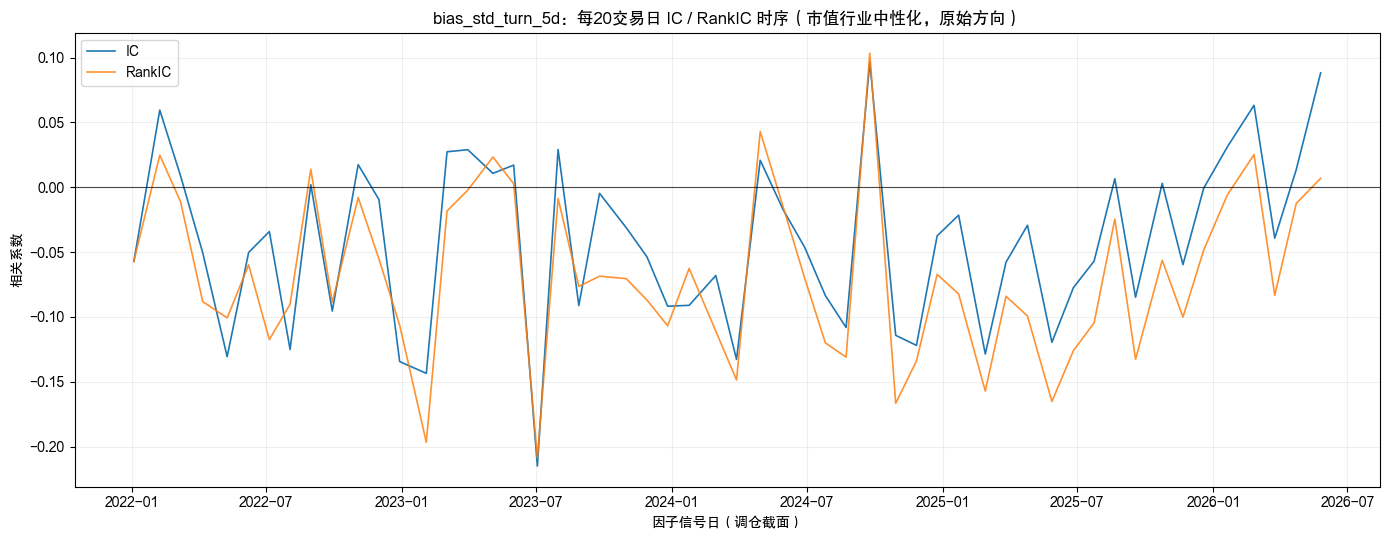

完成。factor_return 为每20个交易日的小数收益单位；原始因子低值优时，IC、RankIC、因子收益率出现负值是方向含义，不是计算错误。


In [1]:
"""
BigQuant：原始 bias_std_turn_5d 因子基础指标测试

因子定义
--------
bias_std_turn_5d = std(turn, 5个交易日) / std(turn, 504个交易日) - 1

计算滚动标准差时剔除 turn <= 0 的观测。因子保持研报中的原始方向，不乘 -1；
因此若“低值优”在样本期成立，IC、RankIC 和因子收益率通常应为负。

评价口径
--------
1. 从 START_DATE 起，每隔 N 个交易日形成一次因子暴露；
2. 标签为本次调仓日收盘到下一次调仓日收盘的收益率；
3. 因子先做截面 MAD 去极值和标准化；
4. 在每个信号截面，将因子对 log(总市值) 和行业哑变量回归，取残差并标准化；
5. IC、RankIC、因子收益率和 t 值全部使用同一列中性化因子；
   因子收益率回归为：下一持有期收益 ~ 截距 + 中性化标准化因子；
6. ICIR、RankICIR 均为均值 / 时间序列样本标准差，不做年化。

代码只输出研究结果，不自动保存运行结果到磁盘。
"""

import time
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd

from bigquant import dai


# =========================
# 可修改参数
# =========================
START_DATE = "2022-01-01"
END_DATE = "2026-06-30"

# 截面/调仓周期。20 表示从区间内首个交易日起，每 20 个交易日取一个截面。
REBALANCE_EVERY_N_TRADING_DAYS = 20

SHORT_WINDOW = 5
LONG_WINDOW = 504              # 约两个交易年
QUERY_LOOKBACK_DAYS = 850      # 给 504 日滚动窗口预留充足自然日
MIN_LIST_DAYS = 730            # 避免长期标准差被极短上市历史主导

MAD_MULTIPLIER = 5.0
MIN_CROSS_SECTION = 80

PROGRESS_EVERY = 12


FACTOR_NAME = "bias_std_turn_5d"
FACTOR_DESCRIPTION = "5日换手率标准差 / 两年换手率标准差 - 1（原始方向，低值优）"


def _validate_parameters() -> None:
    if SHORT_WINDOW < 2:
        raise ValueError("SHORT_WINDOW 必须至少为 2")
    if LONG_WINDOW <= SHORT_WINDOW:
        raise ValueError("LONG_WINDOW 必须大于 SHORT_WINDOW")
    if MIN_CROSS_SECTION < 10:
        raise ValueError("MIN_CROSS_SECTION 不应小于 10")
    if not isinstance(REBALANCE_EVERY_N_TRADING_DAYS, int):
        raise TypeError("REBALANCE_EVERY_N_TRADING_DAYS 必须是整数")
    if REBALANCE_EVERY_N_TRADING_DAYS < 1:
        raise ValueError("REBALANCE_EVERY_N_TRADING_DAYS 必须至少为 1")


def _date_with_offset(date: str, days: int) -> str:
    return (pd.Timestamp(date) + pd.Timedelta(days=days)).strftime("%Y-%m-%d")


def query_rebalance_panel() -> pd.DataFrame:
    """查询每 N 个交易日的截面，并在数据库端计算滚动换手率标准差。"""
    query_start = _date_with_offset(START_DATE, -QUERY_LOOKBACK_DAYS)
    # 查询范围须覆盖 END_DATE 后至少一个完整 N 日周期，供最后一期生成标签。
    label_buffer_days = max(45, 2 * REBALANCE_EVERY_N_TRADING_DAYS + 20)
    query_end = _date_with_offset(END_DATE, label_buffer_days)

    sql = f"""
    WITH trading_dates AS (
        SELECT DISTINCT date
        FROM cn_stock_prefactors
        WHERE date >= '{START_DATE}'
          AND date <= '{query_end}'
    ),
    numbered_trading_dates AS (
        SELECT
            date,
            row_number() OVER (ORDER BY date) AS trading_day_number
        FROM trading_dates
    ),
    selected_dates AS (
        SELECT
            date,
            row_number() OVER (ORDER BY date) AS rebalance_index
        FROM numbered_trading_dates
        WHERE mod(trading_day_number - 1, {REBALANCE_EVERY_N_TRADING_DAYS}) = 0
    ),
    daily_factor AS (
        SELECT
            date,
            instrument,
            close,
            total_market_cap,
            float_market_cap,
            sw2014_level1 AS industry,
            st_status,
            suspended,
            list_days,
            m_stddev(if(turn > 0, turn, NULL), {SHORT_WINDOW}) AS turn_std_short,
            m_stddev(if(turn > 0, turn, NULL), {LONG_WINDOW}) AS turn_std_long
        FROM cn_stock_prefactors
    )
    SELECT
        f.date,
        d.rebalance_index,
        f.instrument,
        f.close,
        f.total_market_cap,
        f.float_market_cap,
        f.industry,
        f.st_status,
        f.suspended,
        f.list_days,
        f.turn_std_short,
        f.turn_std_long,
        f.turn_std_short / nullif(f.turn_std_long, 0) - 1 AS {FACTOR_NAME}
    FROM daily_factor f
    INNER JOIN selected_dates d
        ON f.date = d.date
    ORDER BY f.date, f.instrument
    """

    print(
        f"[1/6] 查询 BigQuant 每 {REBALANCE_EVERY_N_TRADING_DAYS} 个交易日截面："
        f"{START_DATE} 至 {END_DATE}，滚动窗口={SHORT_WINDOW}/{LONG_WINDOW}个交易日"
    )
    started = time.time()
    result = dai.query(
        sql,
        filters={"date": [query_start, query_end]},
    ).df()
    if result is None or result.empty:
        raise ValueError(
            "BigQuant 查询结果为空。请检查日期范围、数据权限以及 "
            "cn_stock_prefactors 中 turn/sw2014_level1 等字段是否可用。"
        )

    result["date"] = pd.to_datetime(result["date"])
    print(
        f"      返回 {len(result):,} 行、{result['date'].nunique():,} 个截面，"
        f"耗时 {time.time() - started:.1f} 秒"
    )
    return result


def add_next_rebalance_return(panel: pd.DataFrame) -> pd.DataFrame:
    """添加下一调仓日收益，并严格排除股票缺失导致的跨期标签。"""
    data = panel.copy()
    data = data.sort_values(["instrument", "date"])

    by_stock = data.groupby("instrument", sort=False)
    data["return_end_date"] = by_stock["date"].shift(-1)
    data["next_rebalance_close"] = by_stock["close"].shift(-1)
    data["next_rebalance_index"] = by_stock["rebalance_index"].shift(-1)

    # 股票若在紧邻的下一调仓截面缺失，不能把更远一期误作 N 日标签。
    is_exact_next_period = data["next_rebalance_index"] == data["rebalance_index"] + 1

    data["forward_return"] = np.where(
        is_exact_next_period,
        data["next_rebalance_close"] / data["close"] - 1.0,
        np.nan,
    )

    signal_start = pd.Timestamp(START_DATE)
    signal_end = pd.Timestamp(END_DATE)
    data = data.loc[data["date"].between(signal_start, signal_end)].copy()

    # 此处保留不完整标签；中性化只能依赖信号日信息，不能根据未来收益是否存在选样本。
    # 不完整标签会在计算基础指标时剔除。
    return data


def mad_winsorize_and_zscore(values: pd.Series) -> pd.Series:
    """截面中位数/MAD去极值后标准化；不改变因子方向。"""
    x = pd.to_numeric(values, errors="coerce").astype(float)
    valid = np.isfinite(x)
    result = pd.Series(np.nan, index=x.index, dtype=float)
    if valid.sum() < 3:
        return result

    xv = x.loc[valid]
    median = xv.median()
    mad = (xv - median).abs().median()

    if np.isfinite(mad) and mad > 0:
        lower = median - MAD_MULTIPLIER * mad
        upper = median + MAD_MULTIPLIER * mad
        xv = xv.clip(lower, upper)

    std = xv.std(ddof=1)
    if not np.isfinite(std) or std <= 0:
        return result
    result.loc[valid] = (xv - xv.mean()) / std
    return result


def zscore(values: pd.Series) -> pd.Series:
    """仅做标准化；用于中性化残差，避免二次去极值破坏正交性。"""
    x = pd.to_numeric(values, errors="coerce").astype(float)
    valid = np.isfinite(x)
    result = pd.Series(np.nan, index=x.index, dtype=float)
    if valid.sum() < 3:
        return result
    xv = x.loc[valid]
    std = xv.std(ddof=1)
    if not np.isfinite(std) or std <= 0:
        return result
    result.loc[valid] = (xv - xv.mean()) / std
    return result


def _industry_design(industry: pd.Series) -> pd.DataFrame:
    values = industry.fillna("UNKNOWN").astype(str)
    return pd.get_dummies(values, prefix="industry", drop_first=True, dtype=float)


def neutralize_factor(
    factor_z: pd.Series,
    log_market_cap: pd.Series,
    industry: pd.Series,
) -> pd.Series:
    """用 OLS 剔除 log(总市值) 和行业对因子暴露的线性影响。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(factor_z, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)

    residual = pd.Series(np.nan, index=factor_z.index, dtype=float)
    if valid.sum() <= design.shape[1] + 2:
        return residual

    x_array = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x_array, y_array, rcond=None)[0]
    residual.loc[valid] = y_array - x_array @ beta
    return zscore(residual)


def factor_return_regression(
    returns: pd.Series,
    neutralized_factor: pd.Series,
) -> Tuple[float, float]:
    """用同一中性化因子做截面 OLS，返回因子收益率及带符号 t 值。"""
    y = pd.to_numeric(returns, errors="coerce")
    factor = pd.to_numeric(neutralized_factor, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(factor)
    y_array = y.loc[valid].to_numpy(dtype=float)
    factor_array = factor.loc[valid].to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(factor_array)), factor_array])
    n_obs, n_params = x.shape
    if n_obs <= n_params + 2:
        return np.nan, np.nan

    xtx_inv = np.linalg.pinv(x.T @ x)
    beta = xtx_inv @ x.T @ y_array
    residual = y_array - x @ beta
    degrees_of_freedom = n_obs - n_params
    residual_variance = float(residual @ residual) / degrees_of_freedom
    covariance = residual_variance * xtx_inv

    factor_beta = float(beta[1])
    factor_se = float(np.sqrt(max(covariance[1, 1], 0.0)))
    factor_t = factor_beta / factor_se if factor_se > 0 else np.nan
    return factor_beta, factor_t


def neutralize_research_sample(sample: pd.DataFrame) -> pd.DataFrame:
    """仅使用各信号日当时的完整有效股票池，逐截面生成市值行业中性化因子。"""
    print("[3/6] 逐截面进行 MAD 去极值、标准化和市值行业中性化")
    dates = sorted(sample["date"].dropna().unique())
    sections = []
    started = time.time()

    for index, signal_date in enumerate(dates, start=1):
        section = sample.loc[sample["date"] == signal_date].copy()
        section["factor_raw_z"] = mad_winsorize_and_zscore(section[FACTOR_NAME])
        section["log_market_cap"] = np.log(section["total_market_cap"].astype(float))
        section["factor_neutralized"] = neutralize_factor(
            section["factor_raw_z"],
            section["log_market_cap"],
            section["industry"],
        )
        neutralization_sample = section.dropna(
            subset=["factor_neutralized", "log_market_cap", "industry"]
        )
        section["neutralization_size_corr_full"] = neutralization_sample[
            "factor_neutralized"
        ].corr(neutralization_sample["log_market_cap"])
        section["neutralization_max_abs_industry_mean_full"] = (
            neutralization_sample.groupby("industry")["factor_neutralized"]
            .mean()
            .abs()
            .max()
        )
        sections.append(section)

        if index % PROGRESS_EVERY == 0 or index == len(dates):
            print(f"      已完成 {index}/{len(dates)} 个中性化截面")

    result = pd.concat(sections, ignore_index=True)
    valid_count = int(result["factor_neutralized"].notna().sum())
    print(
        f"      中性化完成，有效暴露 {valid_count:,} 条，"
        f"耗时 {time.time() - started:.1f} 秒"
    )
    return result


def calculate_cross_section_metrics(section: pd.DataFrame) -> Optional[Dict]:
    """使用同一列中性化因子计算单个调仓截面的全部基础指标。"""
    sample = section.dropna(
        subset=["factor_neutralized", "forward_return", "log_market_cap", "industry"]
    ).copy()
    sample = sample.loc[
        np.isfinite(sample["factor_neutralized"])
        & np.isfinite(sample["forward_return"])
        & np.isfinite(sample["log_market_cap"])
    ].copy()
    if len(sample) < MIN_CROSS_SECTION:
        return None

    ic = sample["factor_neutralized"].corr(sample["forward_return"], method="pearson")
    rank_ic = sample["factor_neutralized"].corr(
        sample["forward_return"], method="spearman"
    )
    factor_return, t_value = factor_return_regression(
        returns=sample["forward_return"],
        neutralized_factor=sample["factor_neutralized"],
    )

    return {
        "signal_date": pd.Timestamp(sample["date"].iloc[0]),
        "return_end_date": pd.Timestamp(sample["return_end_date"].iloc[0]),
        "sample_count": int(len(sample)),
        "ic": float(ic),
        "rank_ic": float(rank_ic),
        "factor_return": factor_return,
        "t_value": t_value,
        "neutralized_size_corr": float(sample["neutralization_size_corr_full"].iloc[0]),
        "neutralized_max_abs_industry_mean": float(
            sample["neutralization_max_abs_industry_mean_full"].iloc[0]
        ),
    }


def prepare_research_sample(panel: pd.DataFrame) -> pd.DataFrame:
    """生成标签并应用信号日可知的基础股票池过滤条件。"""
    print(
        f"[2/6] 构造相邻 {REBALANCE_EVERY_N_TRADING_DAYS} 交易日截面的收益标签，"
        "并过滤基础股票池"
    )
    data = add_next_rebalance_return(panel)

    numeric_columns = [
        FACTOR_NAME,
        "close",
        "total_market_cap",
        "float_market_cap",
        "list_days",
        "st_status",
        "suspended",
    ]
    for column in numeric_columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    eligible = (
        data[FACTOR_NAME].notna()
        & np.isfinite(data[FACTOR_NAME])
        & (data["turn_std_long"] > 0)
        & (data["close"] > 0)
        & (data["total_market_cap"] > 0)
        & (data["float_market_cap"] > 0)
        & (data["list_days"] >= MIN_LIST_DAYS)
        & (data["st_status"] == 0)
        & (data["suspended"] == 0)
        & data["industry"].notna()
    )
    data = data.loc[eligible].copy()
    print(
        f"      有效样本 {len(data):,} 行，"
        f"信号期 {data['date'].min().date()} 至 {data['date'].max().date()}"
    )
    return data


def calculate_metric_timeseries(sample: pd.DataFrame) -> pd.DataFrame:
    print(
        f"[4/6] 逐截面计算基础指标 | 暴露=市值行业中性化因子 | "
        f"最小截面={MIN_CROSS_SECTION}"
    )
    dates = sorted(sample["date"].dropna().unique())
    rows = []
    started = time.time()
    for index, signal_date in enumerate(dates, start=1):
        result = calculate_cross_section_metrics(sample.loc[sample["date"] == signal_date])
        if result is not None:
            rows.append(result)
        if index % PROGRESS_EVERY == 0 or index == len(dates):
            print(f"      已完成 {index}/{len(dates)} 个截面")

    metrics = pd.DataFrame(rows).sort_values("signal_date").reset_index(drop=True)
    if metrics.empty:
        raise ValueError("没有截面满足基础指标计算条件，请检查日期和股票池参数")
    print(f"      得到 {len(metrics)} 个有效截面，耗时 {time.time() - started:.1f} 秒")
    return metrics


def _mean_over_sample_std(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="coerce").dropna()
    std = values.std(ddof=1)
    if len(values) < 2 or not np.isfinite(std) or std <= 0:
        return np.nan
    return float(values.mean() / std)


def summarize_metrics(metrics: pd.DataFrame) -> pd.DataFrame:
    """汇总技能约定的六项基础指标。"""
    row = {
        "因子名称": FACTOR_NAME,
        "因子含义": FACTOR_DESCRIPTION,
        "基础指标口径": "全部使用市值行业中性化后的标准化残差",
        "截面周期": f"每{REBALANCE_EVERY_N_TRADING_DAYS}个交易日",
        "收益周期": f"本次截面至下一次截面（{REBALANCE_EVERY_N_TRADING_DAYS}个交易日）",
        "有效截面数": int(len(metrics)),
        "平均样本数": float(metrics["sample_count"].mean()),
        "IC均值": float(metrics["ic"].mean()),
        "RankIC均值": float(metrics["rank_ic"].mean()),
        "ICIR": _mean_over_sample_std(metrics["ic"]),
        "RankICIR": _mean_over_sample_std(metrics["rank_ic"]),
        "因子收益率均值": float(metrics["factor_return"].mean()),
        "t均值": float(metrics["t_value"].mean()),
        "平均|中性化后市值相关|": float(metrics["neutralized_size_corr"].abs().mean()),
        "平均中性化后行业均值最大绝对值": float(
            metrics["neutralized_max_abs_industry_mean"].mean()
        ),
    }
    return pd.DataFrame([row])


def format_summary_for_display(summary: pd.DataFrame) -> pd.DataFrame:
    display_table = summary.copy()
    for column in ["IC均值", "RankIC均值", "因子收益率均值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.2%}" if pd.notna(x) else "NA"
        )
    for column in ["ICIR", "RankICIR", "t均值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.3f}" if pd.notna(x) else "NA"
        )
    display_table["平均样本数"] = display_table["平均样本数"].map(lambda x: f"{x:.0f}")
    for column in ["平均|中性化后市值相关|", "平均中性化后行业均值最大绝对值"]:
        display_table[column] = display_table[column].map(
            lambda x: f"{x:.2e}" if pd.notna(x) else "NA"
        )
    return display_table


def _configure_chinese_font() -> None:
    candidates = [
        "Noto Sans CJK SC",
        "Source Han Sans CN",
        "Microsoft YaHei",
        "SimHei",
        "Arial Unicode MS",
    ]
    installed = {font.name for font in font_manager.fontManager.ttflist}
    for candidate in candidates:
        if candidate in installed:
            plt.rcParams["font.sans-serif"] = [candidate]
            break
    plt.rcParams["axes.unicode_minus"] = False


def plot_ic_timeseries(metrics: pd.DataFrame):
    """在同一张 Python 图中绘制 IC 与 RankIC 时序。"""
    _configure_chinese_font()
    figure, axis = plt.subplots(figsize=(14, 5.5))
    axis.plot(metrics["signal_date"], metrics["ic"], label="IC", linewidth=1.2)
    axis.plot(
        metrics["signal_date"],
        metrics["rank_ic"],
        label="RankIC",
        linewidth=1.2,
        alpha=0.85,
    )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    axis.set_title(
        f"{FACTOR_NAME}：每{REBALANCE_EVERY_N_TRADING_DAYS}交易日 "
        "IC / RankIC 时序（市值行业中性化，原始方向）"
    )
    axis.set_xlabel("因子信号日（调仓截面）")
    axis.set_ylabel("相关系数")
    axis.grid(alpha=0.2)
    axis.legend()
    figure.tight_layout()
    plt.show()
    return figure, axis


def main() -> Dict[str, object]:
    _validate_parameters()
    panel = query_rebalance_panel()
    sample = prepare_research_sample(panel)
    neutralized_sample = neutralize_research_sample(sample)
    metrics = calculate_metric_timeseries(neutralized_sample)

    print("[5/6] 汇总基础指标")
    summary = summarize_metrics(metrics)
    display_summary = format_summary_for_display(summary)
    try:
        from IPython.display import display

        display(display_summary)
    except ImportError:
        print(display_summary.to_string(index=False))

    print(f"[6/6] 绘制每 {REBALANCE_EVERY_N_TRADING_DAYS} 交易日 IC / RankIC 时序图")
    figure, axis = plot_ic_timeseries(metrics)

    print(
        f"完成。factor_return 为每{REBALANCE_EVERY_N_TRADING_DAYS}个交易日的"
        "小数收益单位；原始因子低值优时，"
        "IC、RankIC、因子收益率出现负值是方向含义，不是计算错误。"
    )
    return {
        "summary": summary,
        "display_summary": display_summary,
        "metric_timeseries": metrics,
        "research_sample": neutralized_sample,
        "figure": figure,
        "axis": axis,
    }


if __name__ == "__main__":
    results = main()


从基础指标计算结果来看，市值行业中性化虽然没有显著提高因子的IC和RankIC，但显著提高了因子的ICIR，使得因子的表现更加稳定，于是后面的市值分组回测将主要使用市值行业中性化后的因子进行

## 第一版市值分组回测

In [2]:
"""
BigQuant：市值行业中性化 bias_std_turn_5d 因子的市值分组回测

因子定义
--------
bias_std_turn_5d = std(turn, 5个交易日) / std(turn, 504个交易日) - 1

滚动标准差剔除 turn <= 0 的观测。因子保持原始方向：低值优，默认在每个
指定市值组内选择中性化因子最低的 k%。

时间顺序
--------
1. t 日收盘后，使用截至 t 日的数据计算因子并做市值行业中性化；
2. 全市场有效股票按 t 日总市值从小到大等数量分为15组；
3. 在参数指定的每个市值组内独立选股，合并后全局等权；
4. t+1 交易日开盘执行；每 N 个市场交易日重新调仓。

脚本不自动保存任何结果。选股、中性化和执行审计表保留在内存中的
RESEARCH_ARTIFACTS，BigTrader 回测结果由 performance 接收。
"""

import math
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd

from bigquant import bigtrader, dai


# =============================================================================
# 1. 参数区
# =============================================================================

START_DATE = "2022-01-01"
END_DATE = "2026-06-30"
CAPITAL_BASE = 1_000_000
BENCHMARK = "000300.SH"

# 第1组为市值最小，第15组为市值最大。
MARKET_CAP_GROUPS = [1, 2, 3]
TOP_K_PCT = 0.05
REBALANCE_DAYS = 20

# 1：取最高 k%；-1：取最低 k%。本因子原始方向低值优，因此默认 -1。
FACTOR_DIRECTION = -1
MARKET_CAP_GROUP_COUNT = 15

SHORT_WINDOW = 5
LONG_WINDOW = 504
QUERY_LOOKBACK_DAYS = 850
MIN_LIST_DAYS = 730
MAD_MULTIPLIER = 5.0
MIN_CROSS_SECTION = 80
PROGRESS_EVERY = 20

# 结合用户可交易范围，默认排除科创板、创业板和北交所；均可修改。
EXCLUDE_STAR_MARKET = True
EXCLUDE_CHINEXT = True
EXCLUDE_BSE = True

# 成本参数按当前 BigTrader 接口拆分为佣金、卖出印花税和滑点。
BUY_COST = 0.0003
SELL_COST = 0.0003
STAMP_TAX = 0.0005
MIN_COMMISSION = 5.0
SLIPPAGE_RATE = 0.001
VOLUME_LIMIT = 0.025
LOG_EACH_REBALANCE = False

DATA_SOURCE = "cn_stock_prefactors"
FACTOR_NAME = "bias_std_turn_5d"


@dataclass(frozen=True)
class StrategyConfig:
    market_cap_groups: tuple
    top_k_pct: float
    rebalance_days: int
    factor_direction: int


_ACTIVE_CONFIG = None

# 不写文件；运行结束后可在 Notebook 中直接查看这些对象。
RESEARCH_ARTIFACTS = {}


def make_config(
    market_cap_groups,
    top_k_pct,
    rebalance_days,
    factor_direction,
):
    config = StrategyConfig(
        market_cap_groups=tuple(int(x) for x in market_cap_groups),
        top_k_pct=float(top_k_pct),
        rebalance_days=int(rebalance_days),
        factor_direction=int(factor_direction),
    )
    validate_config(config)
    return config


def validate_config(config):
    if not config.market_cap_groups:
        raise ValueError("market_cap_groups 不能为空")
    invalid = sorted(
        set(config.market_cap_groups) - set(range(1, MARKET_CAP_GROUP_COUNT + 1))
    )
    if invalid:
        raise ValueError(f"市值组必须位于1~15，错误值：{invalid}")
    if len(set(config.market_cap_groups)) != len(config.market_cap_groups):
        raise ValueError("market_cap_groups 不应包含重复编号")
    if not 0 < config.top_k_pct <= 1:
        raise ValueError("top_k_pct 必须位于 (0, 1] 区间")
    if config.rebalance_days < 1:
        raise ValueError("rebalance_days 必须为正整数")
    if config.factor_direction not in (1, -1):
        raise ValueError("factor_direction 只能为 1 或 -1")
    if SHORT_WINDOW < 2 or LONG_WINDOW <= SHORT_WINDOW:
        raise ValueError("因子窗口必须满足 2 <= SHORT_WINDOW < LONG_WINDOW")
    if MIN_CROSS_SECTION < 10:
        raise ValueError("MIN_CROSS_SECTION 不应小于10")


def _date_text(value):
    return pd.Timestamp(value).strftime("%Y-%m-%d")


def _progress(stage, completed, total, started_at, current_item=""):
    if total <= 0:
        return
    elapsed = time.time() - started_at
    rate = completed / elapsed if elapsed > 0 else 0.0
    remaining = (total - completed) / rate if rate > 0 else np.nan
    eta = f"{remaining:.0f}s" if np.isfinite(remaining) else "--"
    print(
        f"[{stage}] {completed}/{total} ({completed / total:.1%}) | "
        f"已用 {elapsed:.0f}s | 预计剩余 {eta} | {current_item}"
    )


# =============================================================================
# 2. 交易日程与BigQuant数据
# =============================================================================

def query_calendar(context, query_start):
    sql = """
    SELECT DISTINCT date
    FROM cn_stock_bar1d
    WHERE date >= $query_start AND date <= $end_date
    ORDER BY date
    """
    result = dai.query(
        sql,
        params={
            "query_start": _date_text(query_start),
            "end_date": _date_text(context.end_date),
        },
    ).df()
    if result.empty:
        raise ValueError("交易日历查询为空")
    return result["date"].tolist()


def build_rebalance_schedule(calendar_dates, start_date, end_date, n_days):
    """生成 (t日收盘信号日, t+1日开盘成交日)。

    第一个信号日取回测区间内首个交易日，因此第一次实际成交发生在下一交易日；
    后续信号日和成交日都严格间隔 N 个市场交易日。
    """
    calendar = sorted({_date_text(x) for x in calendar_dates})
    start_text = _date_text(start_date)
    end_text = _date_text(end_date)
    signal_candidates = [
        date for date in calendar if start_text <= date < end_text
    ]
    next_date = {
        calendar[index]: calendar[index + 1]
        for index in range(len(calendar) - 1)
    }

    schedule = []
    for signal_date in signal_candidates[::n_days]:
        trade_date = next_date.get(signal_date)
        if trade_date is not None and trade_date <= end_text:
            schedule.append((signal_date, trade_date))
    if not schedule:
        raise ValueError("无法生成调仓日程，请检查回测区间")
    return schedule


def _sql_date_literals(dates):
    normalized = sorted({_date_text(value) for value in dates})
    if not normalized:
        raise ValueError("待查询日期列表不能为空")
    return ", ".join(f"'{date}'" for date in normalized)


def query_required_cross_sections(query_start, query_end, needed_dates):
    """
    先在连续日频历史上计算滚动窗口，再连接独立的信号日期表取截面。

    不直接对 daily_factor 使用 ``WHERE date IN (...)``：BigQuant 的 m_ 系列
    窗口算子可能受到日期谓词下推影响，导致504日窗口只看到稀疏信号日。
    filters额外提供约850个自然日的历史，供504交易日窗口预热。
    """
    date_literals = _sql_date_literals(needed_dates)
    sql = f"""
    WITH selected_dates AS (
        SELECT DISTINCT date
        FROM cn_stock_bar1d
        WHERE date IN ({date_literals})
    ),
    daily_factor AS (
        SELECT
            date,
            instrument,
            total_market_cap,
            sw2014_level1 AS industry,
            st_status,
            suspended,
            list_days,
            m_stddev(if(turn > 0, turn, NULL), {SHORT_WINDOW}) AS turn_std_short,
            m_stddev(if(turn > 0, turn, NULL), {LONG_WINDOW}) AS turn_std_long
        FROM {DATA_SOURCE}
    )
    SELECT
        f.date,
        f.instrument,
        f.total_market_cap,
        f.industry,
        f.st_status,
        f.suspended,
        f.list_days,
        f.turn_std_short,
        f.turn_std_long,
        f.turn_std_short / nullif(f.turn_std_long, 0) - 1 AS {FACTOR_NAME}
    FROM daily_factor f
    INNER JOIN selected_dates d
        ON f.date = d.date
    ORDER BY f.date, f.instrument
    """
    result = dai.query(
        sql,
        filters={"date": [_date_text(query_start), _date_text(query_end)]},
    ).df()
    if not result.empty:
        return result

    probe_date = sorted({_date_text(x) for x in needed_dates})[0]
    probe = dai.query(
        f"""
        SELECT COUNT(*) AS row_count
        FROM {DATA_SOURCE}
        WHERE date = '{probe_date}'
        """,
        filters={"date": [probe_date, probe_date]},
    ).df()
    probe_count = int(probe.iloc[0]["row_count"]) if not probe.empty else -1
    raise ValueError(
        "BigQuant截面查询为空："
        f"日期数={len(set(needed_dates))}，探针日期={probe_date}，"
        f"探针行数={probe_count}。请检查日期覆盖、字段权限和SQL算子。"
    )


# =============================================================================
# 3. 因子清洗与市值行业中性化
# =============================================================================

def mad_winsorize(series, multiplier=MAD_MULTIPLIER):
    values = pd.to_numeric(series, errors="coerce").astype(float)
    values = values.replace([np.inf, -np.inf], np.nan)
    valid = values.dropna()
    if valid.empty:
        return values
    median = valid.median()
    mad = (valid - median).abs().median()
    if not np.isfinite(mad) or mad <= 0:
        return values
    return values.clip(median - multiplier * mad, median + multiplier * mad)


def zscore(series):
    values = pd.to_numeric(series, errors="coerce").astype(float)
    result = pd.Series(np.nan, index=series.index, dtype=float)
    valid = np.isfinite(values)
    if valid.sum() < 3:
        return result
    sample = values.loc[valid]
    standard_deviation = sample.std(ddof=1)
    if not np.isfinite(standard_deviation) or standard_deviation <= 0:
        return result
    result.loc[valid] = (sample - sample.mean()) / standard_deviation
    return result


def _industry_design(industry):
    values = industry.fillna("UNKNOWN").astype(str)
    return pd.get_dummies(values, prefix="industry", drop_first=True, dtype=float)


def neutralize_factor(factor_z, log_market_cap, industry):
    """OLS：factor_z ~ 截距 + log(总市值) + 行业哑变量；返回标准化残差。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(factor_z, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)

    residual = pd.Series(np.nan, index=factor_z.index, dtype=float)
    if valid.sum() <= design.shape[1] + 2:
        return residual
    x_array = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x_array, y_array, rcond=None)[0]
    residual.loc[valid] = y_array - x_array @ beta
    return zscore(residual)


def _board_allowed(instrument):
    code = str(instrument).upper()
    if EXCLUDE_BSE and code.endswith(".BJ"):
        return False
    if EXCLUDE_STAR_MARKET and code.endswith(".SH"):
        numeric = code.split(".")[0]
        if numeric.startswith(("688", "689")):
            return False
    if EXCLUDE_CHINEXT and code.endswith(".SZ"):
        numeric = code.split(".")[0]
        if numeric.startswith(("300", "301")):
            return False
    return True


def prepare_neutralized_signal_panel(raw_data, signal_dates):
    """
    中性化使用信号日全部合格股票，与随后选择哪些市值组无关。
    因此不会在小盘组内部单独回归，也不会用未来收益筛样本。
    """
    signal_set = set(signal_dates)
    source = raw_data[raw_data["date"].isin(signal_set)]
    data_by_date = {date: group for date, group in source.groupby("date", sort=False)}
    output = []
    audit = []
    started = time.time()
    dates = sorted(signal_set)

    for index, signal_date in enumerate(dates, start=1):
        day = data_by_date.get(signal_date)
        if day is None or day.empty:
            continue
        day = day.drop_duplicates("instrument", keep="last").copy()
        board_mask = day["instrument"].map(_board_allowed)
        eligible = day[
            board_mask
            & (day["st_status"] == 0)
            & (day["suspended"] == 0)
            & (day["list_days"] >= MIN_LIST_DAYS)
            & day["total_market_cap"].notna()
            & (day["total_market_cap"] > 0)
        ].copy()

        eligible["factor_raw_z"] = zscore(
            mad_winsorize(eligible[FACTOR_NAME])
        )
        eligible["log_market_cap"] = np.log(
            eligible["total_market_cap"].astype(float)
        )
        # 缺失行业的股票不能真正做到“行业中性”，因此不纳入回归；
        # 截面太小时也不强行拟合，防止残差被少量行业哑变量过拟合。
        eligible["factor_neutralized"] = np.nan
        neutralizable = eligible[
            eligible["factor_raw_z"].notna()
            & eligible["log_market_cap"].notna()
            & eligible["industry"].notna()
        ].copy()
        if len(neutralizable) >= MIN_CROSS_SECTION:
            eligible.loc[
                neutralizable.index, "factor_neutralized"
            ] = neutralize_factor(
                neutralizable["factor_raw_z"],
                neutralizable["log_market_cap"],
                neutralizable["industry"],
            )

        neutral_sample = eligible.dropna(
            subset=["factor_neutralized", "log_market_cap", "industry"]
        )
        size_corr = neutral_sample["factor_neutralized"].corr(
            neutral_sample["log_market_cap"]
        )
        industry_bias = (
            neutral_sample.groupby("industry")["factor_neutralized"]
            .mean()
            .abs()
            .max()
            if not neutral_sample.empty
            else np.nan
        )
        audit.append(
            {
                "signal_date": signal_date,
                "eligible_stock_count": int(len(eligible)),
                "neutralization_input_count": int(len(neutralizable)),
                "neutralized_factor_count": int(len(neutral_sample)),
                "neutralized_size_corr": float(size_corr),
                "neutralized_max_abs_industry_mean": float(industry_bias),
            }
        )
        output.append(
            eligible[
                [
                    "date",
                    "instrument",
                    "total_market_cap",
                    FACTOR_NAME,
                    "factor_raw_z",
                    "factor_neutralized",
                ]
            ]
        )

        if index == 1 or index == len(dates) or index % PROGRESS_EVERY == 0:
            _progress("因子中性化", index, len(dates), started, signal_date)

    panel = pd.concat(output, ignore_index=True) if output else pd.DataFrame()
    return panel, pd.DataFrame(audit)


# =============================================================================
# 4. 市值15组与组内独立选股
# =============================================================================

def assign_market_cap_groups(cross_section, group_count=MARKET_CAP_GROUP_COUNT):
    """按股票数量分位分组，而非按市值数值区间等宽分组。"""
    frame = cross_section.sort_values(
        ["total_market_cap", "instrument"], ascending=[True, True]
    ).copy()
    if len(frame) < group_count:
        return frame.iloc[0:0].assign(market_cap_group=pd.Series(dtype="int64"))
    cap_rank = frame["total_market_cap"].rank(method="first", ascending=True)
    frame["market_cap_group"] = pd.qcut(
        cap_rank,
        q=group_count,
        labels=list(range(1, group_count + 1)),
    ).astype(int)
    return frame


def select_one_signal_date(day_data, config):
    universe = day_data[
        day_data["total_market_cap"].notna()
        & (day_data["total_market_cap"] > 0)
    ].drop_duplicates("instrument", keep="last")
    grouped = assign_market_cap_groups(universe)
    if grouped.empty:
        return [], []

    selected = []
    audit = []
    positive = config.factor_direction == 1
    for group_number in config.market_cap_groups:
        group_all = grouped[grouped["market_cap_group"] == group_number]
        group_valid = group_all[
            group_all["factor_neutralized"].notna()
            & np.isfinite(group_all["factor_neutralized"].astype(float))
        ]
        select_count = (
            max(1, int(math.ceil(len(group_valid) * config.top_k_pct)))
            if len(group_valid)
            else 0
        )
        picked = group_valid.sort_values(
            ["factor_neutralized", "instrument"],
            ascending=[not positive, True],
        ).head(select_count)
        selected.extend(picked["instrument"].tolist())
        audit.append(
            {
                "market_cap_group": int(group_number),
                "group_stock_count": int(len(group_all)),
                "valid_factor_count": int(len(group_valid)),
                "selected_count": int(len(picked)),
            }
        )
    return list(dict.fromkeys(selected)), audit


def build_targets_and_audit(factor_panel, schedule, config):
    data_by_date = {date: group for date, group in factor_panel.groupby("date")}
    targets_by_signal_date = {}
    audit_records = []
    started = time.time()

    for index, (signal_date, trade_date) in enumerate(schedule, start=1):
        day = data_by_date.get(signal_date)
        if day is None or day.empty:
            continue
        targets, day_audit = select_one_signal_date(day, config)
        for row in day_audit:
            row.update(
                {
                    "signal_date": signal_date,
                    "trade_date": trade_date,
                    "factor_name": FACTOR_NAME,
                    "factor_exposure": "market_cap_industry_neutralized",
                    "target_stock_count": int(len(targets)),
                }
            )
            audit_records.append(row)

        if not targets:
            continue
        targets_by_signal_date[signal_date] = {
            "trade_date": trade_date,
            "instruments": targets,
        }

        if index == 1 or index == len(schedule) or index % PROGRESS_EVERY == 0:
            _progress("市值分组与选股", index, len(schedule), started, signal_date)

    return targets_by_signal_date, pd.DataFrame(audit_records)


# =============================================================================
# 5. BigTrader初始化与成交约束
# =============================================================================

def initialize(context):
    config = _ACTIVE_CONFIG
    if config is None:
        raise RuntimeError("请通过 run_backtest(...) 启动策略")
    validate_config(config)
    context.config = config
    context.set_commission(
        bigtrader.PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COMMISSION,
            tax_ratio=STAMP_TAX,
        )
    )
    context.set_slippage_value(
        slippage_type=2,
        slippage_value=SLIPPAGE_RATE,
    )

    query_start = pd.Timestamp(context.start_date) - pd.Timedelta(
        days=QUERY_LOOKBACK_DAYS
    )

    print("[1/5] 查询交易日历并生成 t日信号、t+1日开盘成交日程")
    calendar_dates = query_calendar(context, query_start)
    schedule = build_rebalance_schedule(
        calendar_dates,
        context.start_date,
        context.end_date,
        config.rebalance_days,
    )
    signal_dates = [signal_date for signal_date, _ in schedule]
    needed_dates = sorted(set(signal_dates))

    print(
        f"[2/5] 查询信号日因子截面 | 因子={FACTOR_NAME} | "
        f"窗口={SHORT_WINDOW}/{LONG_WINDOW}交易日"
    )
    raw_data = query_required_cross_sections(
        query_start=query_start,
        query_end=context.end_date,
        needed_dates=needed_dates,
    )
    raw_data["date"] = pd.to_datetime(raw_data["date"]).dt.strftime("%Y-%m-%d")
    raw_data["instrument"] = raw_data["instrument"].astype(str)
    numeric_columns = [
        "total_market_cap",
        "st_status",
        "suspended",
        "list_days",
        "turn_std_short",
        "turn_std_long",
        FACTOR_NAME,
    ]
    for column in numeric_columns:
        raw_data[column] = pd.to_numeric(raw_data[column], errors="coerce")

    raw_data[FACTOR_NAME] = raw_data[FACTOR_NAME].replace(
        [np.inf, -np.inf], np.nan
    )
    valid_by_date = raw_data.groupby("date")[FACTOR_NAME].count()
    valid_window_dates = valid_by_date[valid_by_date >= MIN_CROSS_SECTION]
    print(
        f"[数据] {len(raw_data):,}行 | {raw_data['instrument'].nunique():,}只股票 | "
        f"{raw_data['date'].min()}至{raw_data['date'].max()}"
    )
    print(
        f"[窗口诊断] 原始因子有效={raw_data[FACTOR_NAME].notna().sum():,}条 | "
        f"有效截面={len(valid_window_dates)}/{len(valid_by_date)} | "
        f"单截面有效数 min/median/max="
        f"{int(valid_by_date.min())}/{valid_by_date.median():.0f}/"
        f"{int(valid_by_date.max())}"
    )
    if valid_window_dates.empty:
        raise ValueError(
            "504日窗口没有生成有效原始因子：所有信号日的 "
            f"{FACTOR_NAME} 有效数均小于 {MIN_CROSS_SECTION}。"
            "请检查窗口历史是否被日期条件裁剪。"
        )

    print("[3/5] 对因子做MAD去极值、标准化及市值行业中性化")
    factor_panel, neutralization_audit = prepare_neutralized_signal_panel(
        raw_data,
        signal_dates,
    )
    if factor_panel.empty:
        raise ValueError("中性化后没有有效因子截面")
    neutralized_valid_dates = neutralization_audit[
        neutralization_audit["neutralized_factor_count"] >= MIN_CROSS_SECTION
    ]
    print(
        f"[中性化诊断] 有效截面={len(neutralized_valid_dates)}/"
        f"{len(neutralization_audit)} | 单截面中性化有效数 min/median/max="
        f"{int(neutralization_audit['neutralized_factor_count'].min())}/"
        f"{neutralization_audit['neutralized_factor_count'].median():.0f}/"
        f"{int(neutralization_audit['neutralized_factor_count'].max())}"
    )
    if neutralized_valid_dates.empty:
        raise ValueError(
            "原始因子已查询成功，但所有截面的中性化有效数均不足。"
            "请查看 neutralization_audit 中的 eligible_stock_count、"
            "neutralization_input_count 和 neutralized_factor_count。"
        )

    print("[4/5] 全市场分15个市值组，在指定组内独立选择最低/最高k%")
    context.targets_by_signal_date, selection_audit = build_targets_and_audit(
        factor_panel,
        schedule,
        config,
    )
    context.execution_audit = []
    context.order_event_audit = []
    context.trade_event_audit = []
    RESEARCH_ARTIFACTS.clear()
    RESEARCH_ARTIFACTS.update(
        {
            "config": config,
            "neutralization_audit": neutralization_audit,
            "selection_audit": selection_audit,
            "execution_audit": context.execution_audit,
            "order_event_audit": context.order_event_audit,
            "trade_event_audit": context.trade_event_audit,
        }
    )
    if not context.targets_by_signal_date:
        group_valid_total = (
            int(selection_audit["valid_factor_count"].sum())
            if not selection_audit.empty
            else 0
        )
        raise ValueError(
            "所有调仓日均无有效候选股票："
            f"指定市值组内有效因子累计数={group_valid_total}。"
            "请查看 RESEARCH_ARTIFACTS['selection_audit']。"
        )

    average_count = np.mean(
        [
            len(item["instruments"])
            for item in context.targets_by_signal_date.values()
        ]
    )
    print(
        f"[5/5] 初始化完成 | 有效调仓={len(context.targets_by_signal_date)}次 | "
        f"平均目标={average_count:.1f}只 | 市值组={list(config.market_cap_groups)} | "
        f"组1最小、组15最大 | t日收盘信号、t+1日开盘成交"
    )


def _submit_target_percent(context, instrument, target_weight):
    """提交目标权重并返回 (是否发送成功, 返回码, 错误信息)。"""
    return_code = context.order_target_percent(instrument, target_weight)
    success = return_code is None or int(return_code) >= 0
    error_message = ""
    if not success and hasattr(context, "get_error_msg"):
        error_message = str(context.get_error_msg(int(return_code)))
    return success, return_code, error_message


def handle_data(context, data):
    # 官方BigTrader日线机制：本K线提交委托，下一根K线开始撮合。
    # 所以此处必须在信号日t下单，才能在t+1开盘成交。
    today = data.current_dt.strftime("%Y-%m-%d")
    rebalance = context.targets_by_signal_date.get(today)
    if rebalance is None:
        return

    targets = rebalance["instruments"]
    expected_trade_date = rebalance["trade_date"]
    target_set = set(targets)
    current_set = set()
    for instrument, position in context.portfolio.positions.items():
        amount = getattr(position, "amount", None)
        if amount is None:
            amount = getattr(position, "current_qty", 0)
        if (amount or 0) > 0:
            current_set.add(instrument)

    target_weight = 1.0 / len(targets)

    submitted = 0
    rejected = 0
    errors = {}
    for instrument in sorted(current_set - target_set):
        success, _, error = _submit_target_percent(context, instrument, 0.0)
        submitted += int(success)
        rejected += int(not success)
        if error:
            errors[error] = errors.get(error, 0) + 1

    for instrument in sorted(targets):
        success, _, error = _submit_target_percent(
            context, instrument, target_weight
        )
        submitted += int(success)
        rejected += int(not success)
        if error:
            errors[error] = errors.get(error, 0) + 1

    audit_row = {
        "signal_date": today,
        "expected_trade_date": expected_trade_date,
        "target_count": int(len(targets)),
        "current_holding_count": int(len(current_set)),
        "submitted_order_count": int(submitted),
        "immediate_rejected_order_count": int(rejected),
        "target_weight_per_stock": float(target_weight),
        "immediate_errors": dict(errors),
    }
    context.execution_audit.append(audit_row)

    if LOG_EACH_REBALANCE or rejected > 0:
        context.logger.info(
            f"{today}生成委托、预计{expected_trade_date}开盘撮合 | "
            f"市值组={list(context.config.market_cap_groups)} | "
            f"目标={len(targets)} | 提交={submitted} | 即时拒绝={rejected}"
        )


def handle_order(context, order):
    """记录委托状态，便于核对停牌、涨跌停或资金约束造成的未成交。"""
    context.order_event_audit.append(
        {
            "instrument": str(getattr(order, "instrument", "")),
            "trading_day": str(getattr(order, "trading_day", "")),
            "order_status": str(getattr(order, "order_status", "")),
            "order_qty": getattr(order, "order_qty", np.nan),
            "filled_qty": getattr(order, "filled_qty", np.nan),
            "status_msg": str(getattr(order, "status_msg", "")),
        }
    )


def handle_trade(context, trade):
    """记录实际成交日与成交价，用于验证t+1开盘执行。"""
    context.trade_event_audit.append(
        {
            "instrument": str(getattr(trade, "instrument", "")),
            "trade_date": str(getattr(trade, "trade_date", "")),
            "filled_qty": getattr(trade, "filled_qty", np.nan),
            "filled_price": getattr(trade, "filled_price", np.nan),
            "filled_money": getattr(trade, "filled_money", np.nan),
        }
    )


# =============================================================================
# 6. 参数化运行入口
# =============================================================================

def run_backtest(
    market_cap_groups=None,
    top_k_pct=TOP_K_PCT,
    rebalance_days=REBALANCE_DAYS,
    factor_direction=FACTOR_DIRECTION,
):
    """
    示例：
        run_backtest([1, 2, 3], 0.10, 20, -1)
        run_backtest([13, 14, 15], 0.20, 10, -1)

    factor_direction=-1 表示每组选择中性化因子最低的 k%。
    """
    global _ACTIVE_CONFIG
    selected_groups = MARKET_CAP_GROUPS if market_cap_groups is None else market_cap_groups
    _ACTIVE_CONFIG = make_config(
        market_cap_groups=selected_groups,
        top_k_pct=top_k_pct,
        rebalance_days=rebalance_days,
        factor_direction=factor_direction,
    )
    return bigtrader.run(
        market=bigtrader.Market.CN_STOCK,
        frequency=bigtrader.Frequency.DAILY,
        start_date=START_DATE,
        end_date=END_DATE,
        capital_base=CAPITAL_BASE,
        benchmark=BENCHMARK,
        initialize=initialize,
        handle_data=handle_data,
        handle_order=handle_order,
        handle_trade=handle_trade,
        order_price_field_buy="open",
        order_price_field_sell="open",
        volume_limit=VOLUME_LIMIT,
    )


if __name__ == "__main__":
    performance = run_backtest(
        market_cap_groups=MARKET_CAP_GROUPS,
        top_k_pct=TOP_K_PCT,
        rebalance_days=REBALANCE_DAYS,
        factor_direction=FACTOR_DIRECTION,
    )


[2026-07-22 13:01:29] [info     ] bigtrader init ..
[2026-07-22 13:01:29] [info     ] bigtrader.run start: market=cn_stock, frequency=1d, mode=backtest, account_type=STOCK, start_date=2022-01-01, end_date=2026-06-30
[2026-07-22 13:01:32] [info     ] bigtrader<backtest> init ..
[2026-07-22 13:01:32] [info     ] prepare data ..
[2026-07-22 13:01:32] [info     ] bar1d_df: (5890930, 16)
[2026-07-22 13:01:44] [info     ] bigtrader use dividend data: (19841, 8)
[1/5] 查询交易日历并生成 t日信号、t+1日开盘成交日程
[2/5] 查询信号日因子截面 | 因子=bias_std_turn_5d | 窗口=5/504交易日
[数据] 288,109行 | 5,710只股票 | 2022-01-04至2026-06-24
[窗口诊断] 原始因子有效=219,850条 | 有效截面=55/55 | 单截面有效数 min/median/max=3001/4181/4626
[3/5] 对因子做MAD去极值、标准化及市值行业中性化
[因子中性化] 1/55 (1.8%) | 已用 0s | 预计剩余 5s | 2022-01-04
[因子中性化] 20/55 (36.4%) | 已用 2s | 预计剩余 3s | 2023-07-31
[因子中性化] 40/55 (72.7%) | 已用 4s | 预计剩余 1s | 2025-03-27
[因子中性化] 55/55 (100.0%) | 已用 5s | 预计剩余 0s | 2026-06-24
[中性化诊断] 有效截面=55/55 | 单截面中性化有效数 min/median/max=1922/2603/2680
[4/5] 全市场分15个市值组，在指定组内独立选择最低/最高

[2026-07-22 13:02:12] [info     ] bigtrader run done.


## bias_std_turn_11d 因子市值分组回测

由于研报当中敏感性测试部分，11d因子的分组回测收益效果最好，于是再测试一下该因子

In [3]:
"""
BigQuant：市值行业中性化 bias_std_turn_11d 因子的市值分组回测

因子定义
--------
bias_std_turn_11d = std(turn, 11个交易日) / std(turn, 504个交易日) - 1

滚动标准差剔除 turn <= 0 的观测。因子保持原始方向：低值优，默认在每个
指定市值组内选择中性化因子最低的 k%。

时间顺序
--------
1. t 日收盘后，使用截至 t 日的数据计算因子并做市值行业中性化；
2. 全市场有效股票按 t 日总市值从小到大等数量分为15组；
3. 在参数指定的每个市值组内独立选股，合并后全局等权；
4. t+1 交易日开盘执行；每 N 个市场交易日重新调仓。

脚本不自动保存任何结果。选股、中性化和执行审计表保留在内存中的
RESEARCH_ARTIFACTS，BigTrader 回测结果由 performance 接收。
"""

import math
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd

from bigquant import bigtrader, dai


# =============================================================================
# 1. 参数区
# =============================================================================

START_DATE = "2022-01-01"
END_DATE = "2026-06-30"
CAPITAL_BASE = 1_000_000
BENCHMARK = "000300.SH"

# 第1组为市值最小，第15组为市值最大。
MARKET_CAP_GROUPS = [1, 2, 3]
TOP_K_PCT = 0.1
REBALANCE_DAYS = 20

# 1：取最高 k%；-1：取最低 k%。本因子原始方向低值优，因此默认 -1。
FACTOR_DIRECTION = -1
MARKET_CAP_GROUP_COUNT = 15

SHORT_WINDOW = 11
LONG_WINDOW = 504
QUERY_LOOKBACK_DAYS = 850
MIN_LIST_DAYS = 730
MAD_MULTIPLIER = 5.0
MIN_CROSS_SECTION = 80
PROGRESS_EVERY = 20

# 结合用户可交易范围，默认排除科创板、创业板和北交所；均可修改。
EXCLUDE_STAR_MARKET = True
EXCLUDE_CHINEXT = True
EXCLUDE_BSE = True

# 成本参数按当前 BigTrader 接口拆分为佣金、卖出印花税和滑点。
BUY_COST = 0.0003
SELL_COST = 0.0003
STAMP_TAX = 0.0005
MIN_COMMISSION = 5.0
SLIPPAGE_RATE = 0.001
VOLUME_LIMIT = 0.025
LOG_EACH_REBALANCE = False

DATA_SOURCE = "cn_stock_prefactors"
FACTOR_NAME = "bias_std_turn_11d"


@dataclass(frozen=True)
class StrategyConfig:
    market_cap_groups: tuple
    top_k_pct: float
    rebalance_days: int
    factor_direction: int


_ACTIVE_CONFIG = None

# 不写文件；运行结束后可在 Notebook 中直接查看这些对象。
RESEARCH_ARTIFACTS = {}


def make_config(
    market_cap_groups,
    top_k_pct,
    rebalance_days,
    factor_direction,
):
    config = StrategyConfig(
        market_cap_groups=tuple(int(x) for x in market_cap_groups),
        top_k_pct=float(top_k_pct),
        rebalance_days=int(rebalance_days),
        factor_direction=int(factor_direction),
    )
    validate_config(config)
    return config


def validate_config(config):
    if not config.market_cap_groups:
        raise ValueError("market_cap_groups 不能为空")
    invalid = sorted(
        set(config.market_cap_groups) - set(range(1, MARKET_CAP_GROUP_COUNT + 1))
    )
    if invalid:
        raise ValueError(f"市值组必须位于1~15，错误值：{invalid}")
    if len(set(config.market_cap_groups)) != len(config.market_cap_groups):
        raise ValueError("market_cap_groups 不应包含重复编号")
    if not 0 < config.top_k_pct <= 1:
        raise ValueError("top_k_pct 必须位于 (0, 1] 区间")
    if config.rebalance_days < 1:
        raise ValueError("rebalance_days 必须为正整数")
    if config.factor_direction not in (1, -1):
        raise ValueError("factor_direction 只能为 1 或 -1")
    if SHORT_WINDOW < 2 or LONG_WINDOW <= SHORT_WINDOW:
        raise ValueError("因子窗口必须满足 2 <= SHORT_WINDOW < LONG_WINDOW")
    if MIN_CROSS_SECTION < 10:
        raise ValueError("MIN_CROSS_SECTION 不应小于10")


def _date_text(value):
    return pd.Timestamp(value).strftime("%Y-%m-%d")


def _progress(stage, completed, total, started_at, current_item=""):
    if total <= 0:
        return
    elapsed = time.time() - started_at
    rate = completed / elapsed if elapsed > 0 else 0.0
    remaining = (total - completed) / rate if rate > 0 else np.nan
    eta = f"{remaining:.0f}s" if np.isfinite(remaining) else "--"
    print(
        f"[{stage}] {completed}/{total} ({completed / total:.1%}) | "
        f"已用 {elapsed:.0f}s | 预计剩余 {eta} | {current_item}"
    )


# =============================================================================
# 2. 交易日程与BigQuant数据
# =============================================================================

def query_calendar(context, query_start):
    sql = """
    SELECT DISTINCT date
    FROM cn_stock_bar1d
    WHERE date >= $query_start AND date <= $end_date
    ORDER BY date
    """
    result = dai.query(
        sql,
        params={
            "query_start": _date_text(query_start),
            "end_date": _date_text(context.end_date),
        },
    ).df()
    if result.empty:
        raise ValueError("交易日历查询为空")
    return result["date"].tolist()


def build_rebalance_schedule(calendar_dates, start_date, end_date, n_days):
    """生成 (t日收盘信号日, t+1日开盘成交日)。

    第一个信号日取回测区间内首个交易日，因此第一次实际成交发生在下一交易日；
    后续信号日和成交日都严格间隔 N 个市场交易日。
    """
    calendar = sorted({_date_text(x) for x in calendar_dates})
    start_text = _date_text(start_date)
    end_text = _date_text(end_date)
    signal_candidates = [
        date for date in calendar if start_text <= date < end_text
    ]
    next_date = {
        calendar[index]: calendar[index + 1]
        for index in range(len(calendar) - 1)
    }

    schedule = []
    for signal_date in signal_candidates[::n_days]:
        trade_date = next_date.get(signal_date)
        if trade_date is not None and trade_date <= end_text:
            schedule.append((signal_date, trade_date))
    if not schedule:
        raise ValueError("无法生成调仓日程，请检查回测区间")
    return schedule


def _sql_date_literals(dates):
    normalized = sorted({_date_text(value) for value in dates})
    if not normalized:
        raise ValueError("待查询日期列表不能为空")
    return ", ".join(f"'{date}'" for date in normalized)


def query_required_cross_sections(query_start, query_end, needed_dates):
    """
    先在连续日频历史上计算滚动窗口，再连接独立的信号日期表取截面。

    不直接对 daily_factor 使用 ``WHERE date IN (...)``：BigQuant 的 m_ 系列
    窗口算子可能受到日期谓词下推影响，导致504日窗口只看到稀疏信号日。
    filters额外提供约850个自然日的历史，供504交易日窗口预热。
    """
    date_literals = _sql_date_literals(needed_dates)
    sql = f"""
    WITH selected_dates AS (
        SELECT DISTINCT date
        FROM cn_stock_bar1d
        WHERE date IN ({date_literals})
    ),
    daily_factor AS (
        SELECT
            date,
            instrument,
            total_market_cap,
            sw2014_level1 AS industry,
            st_status,
            suspended,
            list_days,
            m_stddev(if(turn > 0, turn, NULL), {SHORT_WINDOW}) AS turn_std_short,
            m_stddev(if(turn > 0, turn, NULL), {LONG_WINDOW}) AS turn_std_long
        FROM {DATA_SOURCE}
    )
    SELECT
        f.date,
        f.instrument,
        f.total_market_cap,
        f.industry,
        f.st_status,
        f.suspended,
        f.list_days,
        f.turn_std_short,
        f.turn_std_long,
        f.turn_std_short / nullif(f.turn_std_long, 0) - 1 AS {FACTOR_NAME}
    FROM daily_factor f
    INNER JOIN selected_dates d
        ON f.date = d.date
    ORDER BY f.date, f.instrument
    """
    result = dai.query(
        sql,
        filters={"date": [_date_text(query_start), _date_text(query_end)]},
    ).df()
    if not result.empty:
        return result

    probe_date = sorted({_date_text(x) for x in needed_dates})[0]
    probe = dai.query(
        f"""
        SELECT COUNT(*) AS row_count
        FROM {DATA_SOURCE}
        WHERE date = '{probe_date}'
        """,
        filters={"date": [probe_date, probe_date]},
    ).df()
    probe_count = int(probe.iloc[0]["row_count"]) if not probe.empty else -1
    raise ValueError(
        "BigQuant截面查询为空："
        f"日期数={len(set(needed_dates))}，探针日期={probe_date}，"
        f"探针行数={probe_count}。请检查日期覆盖、字段权限和SQL算子。"
    )


# =============================================================================
# 3. 因子清洗与市值行业中性化
# =============================================================================

def mad_winsorize(series, multiplier=MAD_MULTIPLIER):
    values = pd.to_numeric(series, errors="coerce").astype(float)
    values = values.replace([np.inf, -np.inf], np.nan)
    valid = values.dropna()
    if valid.empty:
        return values
    median = valid.median()
    mad = (valid - median).abs().median()
    if not np.isfinite(mad) or mad <= 0:
        return values
    return values.clip(median - multiplier * mad, median + multiplier * mad)


def zscore(series):
    values = pd.to_numeric(series, errors="coerce").astype(float)
    result = pd.Series(np.nan, index=series.index, dtype=float)
    valid = np.isfinite(values)
    if valid.sum() < 3:
        return result
    sample = values.loc[valid]
    standard_deviation = sample.std(ddof=1)
    if not np.isfinite(standard_deviation) or standard_deviation <= 0:
        return result
    result.loc[valid] = (sample - sample.mean()) / standard_deviation
    return result


def _industry_design(industry):
    values = industry.fillna("UNKNOWN").astype(str)
    return pd.get_dummies(values, prefix="industry", drop_first=True, dtype=float)


def neutralize_factor(factor_z, log_market_cap, industry):
    """OLS：factor_z ~ 截距 + log(总市值) + 行业哑变量；返回标准化残差。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(factor_z, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)

    residual = pd.Series(np.nan, index=factor_z.index, dtype=float)
    if valid.sum() <= design.shape[1] + 2:
        return residual
    x_array = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x_array, y_array, rcond=None)[0]
    residual.loc[valid] = y_array - x_array @ beta
    return zscore(residual)


def _board_allowed(instrument):
    code = str(instrument).upper()
    if EXCLUDE_BSE and code.endswith(".BJ"):
        return False
    if EXCLUDE_STAR_MARKET and code.endswith(".SH"):
        numeric = code.split(".")[0]
        if numeric.startswith(("688", "689")):
            return False
    if EXCLUDE_CHINEXT and code.endswith(".SZ"):
        numeric = code.split(".")[0]
        if numeric.startswith(("300", "301")):
            return False
    return True


def prepare_neutralized_signal_panel(raw_data, signal_dates):
    """
    中性化使用信号日全部合格股票，与随后选择哪些市值组无关。
    因此不会在小盘组内部单独回归，也不会用未来收益筛样本。
    """
    signal_set = set(signal_dates)
    source = raw_data[raw_data["date"].isin(signal_set)]
    data_by_date = {date: group for date, group in source.groupby("date", sort=False)}
    output = []
    audit = []
    started = time.time()
    dates = sorted(signal_set)

    for index, signal_date in enumerate(dates, start=1):
        day = data_by_date.get(signal_date)
        if day is None or day.empty:
            continue
        day = day.drop_duplicates("instrument", keep="last").copy()
        board_mask = day["instrument"].map(_board_allowed)
        eligible = day[
            board_mask
            & (day["st_status"] == 0)
            & (day["suspended"] == 0)
            & (day["list_days"] >= MIN_LIST_DAYS)
            & day["total_market_cap"].notna()
            & (day["total_market_cap"] > 0)
        ].copy()

        eligible["factor_raw_z"] = zscore(
            mad_winsorize(eligible[FACTOR_NAME])
        )
        eligible["log_market_cap"] = np.log(
            eligible["total_market_cap"].astype(float)
        )
        # 缺失行业的股票不能真正做到“行业中性”，因此不纳入回归；
        # 截面太小时也不强行拟合，防止残差被少量行业哑变量过拟合。
        eligible["factor_neutralized"] = np.nan
        neutralizable = eligible[
            eligible["factor_raw_z"].notna()
            & eligible["log_market_cap"].notna()
            & eligible["industry"].notna()
        ].copy()
        if len(neutralizable) >= MIN_CROSS_SECTION:
            eligible.loc[
                neutralizable.index, "factor_neutralized"
            ] = neutralize_factor(
                neutralizable["factor_raw_z"],
                neutralizable["log_market_cap"],
                neutralizable["industry"],
            )

        neutral_sample = eligible.dropna(
            subset=["factor_neutralized", "log_market_cap", "industry"]
        )
        size_corr = neutral_sample["factor_neutralized"].corr(
            neutral_sample["log_market_cap"]
        )
        industry_bias = (
            neutral_sample.groupby("industry")["factor_neutralized"]
            .mean()
            .abs()
            .max()
            if not neutral_sample.empty
            else np.nan
        )
        audit.append(
            {
                "signal_date": signal_date,
                "eligible_stock_count": int(len(eligible)),
                "neutralization_input_count": int(len(neutralizable)),
                "neutralized_factor_count": int(len(neutral_sample)),
                "neutralized_size_corr": float(size_corr),
                "neutralized_max_abs_industry_mean": float(industry_bias),
            }
        )
        output.append(
            eligible[
                [
                    "date",
                    "instrument",
                    "total_market_cap",
                    FACTOR_NAME,
                    "factor_raw_z",
                    "factor_neutralized",
                ]
            ]
        )

        if index == 1 or index == len(dates) or index % PROGRESS_EVERY == 0:
            _progress("因子中性化", index, len(dates), started, signal_date)

    panel = pd.concat(output, ignore_index=True) if output else pd.DataFrame()
    return panel, pd.DataFrame(audit)


# =============================================================================
# 4. 市值15组与组内独立选股
# =============================================================================

def assign_market_cap_groups(cross_section, group_count=MARKET_CAP_GROUP_COUNT):
    """按股票数量分位分组，而非按市值数值区间等宽分组。"""
    frame = cross_section.sort_values(
        ["total_market_cap", "instrument"], ascending=[True, True]
    ).copy()
    if len(frame) < group_count:
        return frame.iloc[0:0].assign(market_cap_group=pd.Series(dtype="int64"))
    cap_rank = frame["total_market_cap"].rank(method="first", ascending=True)
    frame["market_cap_group"] = pd.qcut(
        cap_rank,
        q=group_count,
        labels=list(range(1, group_count + 1)),
    ).astype(int)
    return frame


def select_one_signal_date(day_data, config):
    universe = day_data[
        day_data["total_market_cap"].notna()
        & (day_data["total_market_cap"] > 0)
    ].drop_duplicates("instrument", keep="last")
    grouped = assign_market_cap_groups(universe)
    if grouped.empty:
        return [], []

    selected = []
    audit = []
    positive = config.factor_direction == 1
    for group_number in config.market_cap_groups:
        group_all = grouped[grouped["market_cap_group"] == group_number]
        group_valid = group_all[
            group_all["factor_neutralized"].notna()
            & np.isfinite(group_all["factor_neutralized"].astype(float))
        ]
        select_count = (
            max(1, int(math.ceil(len(group_valid) * config.top_k_pct)))
            if len(group_valid)
            else 0
        )
        picked = group_valid.sort_values(
            ["factor_neutralized", "instrument"],
            ascending=[not positive, True],
        ).head(select_count)
        selected.extend(picked["instrument"].tolist())
        audit.append(
            {
                "market_cap_group": int(group_number),
                "group_stock_count": int(len(group_all)),
                "valid_factor_count": int(len(group_valid)),
                "selected_count": int(len(picked)),
            }
        )
    return list(dict.fromkeys(selected)), audit


def build_targets_and_audit(factor_panel, schedule, config):
    data_by_date = {date: group for date, group in factor_panel.groupby("date")}
    targets_by_signal_date = {}
    audit_records = []
    started = time.time()

    for index, (signal_date, trade_date) in enumerate(schedule, start=1):
        day = data_by_date.get(signal_date)
        if day is None or day.empty:
            continue
        targets, day_audit = select_one_signal_date(day, config)
        for row in day_audit:
            row.update(
                {
                    "signal_date": signal_date,
                    "trade_date": trade_date,
                    "factor_name": FACTOR_NAME,
                    "factor_exposure": "market_cap_industry_neutralized",
                    "target_stock_count": int(len(targets)),
                }
            )
            audit_records.append(row)

        if not targets:
            continue
        targets_by_signal_date[signal_date] = {
            "trade_date": trade_date,
            "instruments": targets,
        }

        if index == 1 or index == len(schedule) or index % PROGRESS_EVERY == 0:
            _progress("市值分组与选股", index, len(schedule), started, signal_date)

    return targets_by_signal_date, pd.DataFrame(audit_records)


# =============================================================================
# 5. BigTrader初始化与成交约束
# =============================================================================

def initialize(context):
    config = _ACTIVE_CONFIG
    if config is None:
        raise RuntimeError("请通过 run_backtest(...) 启动策略")
    validate_config(config)
    context.config = config
    context.set_commission(
        bigtrader.PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COMMISSION,
            tax_ratio=STAMP_TAX,
        )
    )
    context.set_slippage_value(
        slippage_type=2,
        slippage_value=SLIPPAGE_RATE,
    )

    query_start = pd.Timestamp(context.start_date) - pd.Timedelta(
        days=QUERY_LOOKBACK_DAYS
    )

    print("[1/5] 查询交易日历并生成 t日信号、t+1日开盘成交日程")
    calendar_dates = query_calendar(context, query_start)
    schedule = build_rebalance_schedule(
        calendar_dates,
        context.start_date,
        context.end_date,
        config.rebalance_days,
    )
    signal_dates = [signal_date for signal_date, _ in schedule]
    needed_dates = sorted(set(signal_dates))

    print(
        f"[2/5] 查询信号日因子截面 | 因子={FACTOR_NAME} | "
        f"窗口={SHORT_WINDOW}/{LONG_WINDOW}交易日"
    )
    raw_data = query_required_cross_sections(
        query_start=query_start,
        query_end=context.end_date,
        needed_dates=needed_dates,
    )
    raw_data["date"] = pd.to_datetime(raw_data["date"]).dt.strftime("%Y-%m-%d")
    raw_data["instrument"] = raw_data["instrument"].astype(str)
    numeric_columns = [
        "total_market_cap",
        "st_status",
        "suspended",
        "list_days",
        "turn_std_short",
        "turn_std_long",
        FACTOR_NAME,
    ]
    for column in numeric_columns:
        raw_data[column] = pd.to_numeric(raw_data[column], errors="coerce")

    raw_data[FACTOR_NAME] = raw_data[FACTOR_NAME].replace(
        [np.inf, -np.inf], np.nan
    )
    valid_by_date = raw_data.groupby("date")[FACTOR_NAME].count()
    valid_window_dates = valid_by_date[valid_by_date >= MIN_CROSS_SECTION]
    print(
        f"[数据] {len(raw_data):,}行 | {raw_data['instrument'].nunique():,}只股票 | "
        f"{raw_data['date'].min()}至{raw_data['date'].max()}"
    )
    print(
        f"[窗口诊断] 原始因子有效={raw_data[FACTOR_NAME].notna().sum():,}条 | "
        f"有效截面={len(valid_window_dates)}/{len(valid_by_date)} | "
        f"单截面有效数 min/median/max="
        f"{int(valid_by_date.min())}/{valid_by_date.median():.0f}/"
        f"{int(valid_by_date.max())}"
    )
    if valid_window_dates.empty:
        raise ValueError(
            "504日窗口没有生成有效原始因子：所有信号日的 "
            f"{FACTOR_NAME} 有效数均小于 {MIN_CROSS_SECTION}。"
            "请检查窗口历史是否被日期条件裁剪。"
        )

    print("[3/5] 对因子做MAD去极值、标准化及市值行业中性化")
    factor_panel, neutralization_audit = prepare_neutralized_signal_panel(
        raw_data,
        signal_dates,
    )
    if factor_panel.empty:
        raise ValueError("中性化后没有有效因子截面")
    neutralized_valid_dates = neutralization_audit[
        neutralization_audit["neutralized_factor_count"] >= MIN_CROSS_SECTION
    ]
    print(
        f"[中性化诊断] 有效截面={len(neutralized_valid_dates)}/"
        f"{len(neutralization_audit)} | 单截面中性化有效数 min/median/max="
        f"{int(neutralization_audit['neutralized_factor_count'].min())}/"
        f"{neutralization_audit['neutralized_factor_count'].median():.0f}/"
        f"{int(neutralization_audit['neutralized_factor_count'].max())}"
    )
    if neutralized_valid_dates.empty:
        raise ValueError(
            "原始因子已查询成功，但所有截面的中性化有效数均不足。"
            "请查看 neutralization_audit 中的 eligible_stock_count、"
            "neutralization_input_count 和 neutralized_factor_count。"
        )

    print("[4/5] 全市场分15个市值组，在指定组内独立选择最低/最高k%")
    context.targets_by_signal_date, selection_audit = build_targets_and_audit(
        factor_panel,
        schedule,
        config,
    )
    context.execution_audit = []
    context.order_event_audit = []
    context.trade_event_audit = []
    RESEARCH_ARTIFACTS.clear()
    RESEARCH_ARTIFACTS.update(
        {
            "config": config,
            "neutralization_audit": neutralization_audit,
            "selection_audit": selection_audit,
            "execution_audit": context.execution_audit,
            "order_event_audit": context.order_event_audit,
            "trade_event_audit": context.trade_event_audit,
        }
    )
    if not context.targets_by_signal_date:
        group_valid_total = (
            int(selection_audit["valid_factor_count"].sum())
            if not selection_audit.empty
            else 0
        )
        raise ValueError(
            "所有调仓日均无有效候选股票："
            f"指定市值组内有效因子累计数={group_valid_total}。"
            "请查看 RESEARCH_ARTIFACTS['selection_audit']。"
        )

    average_count = np.mean(
        [
            len(item["instruments"])
            for item in context.targets_by_signal_date.values()
        ]
    )
    print(
        f"[5/5] 初始化完成 | 有效调仓={len(context.targets_by_signal_date)}次 | "
        f"平均目标={average_count:.1f}只 | 市值组={list(config.market_cap_groups)} | "
        f"组1最小、组15最大 | t日收盘信号、t+1日开盘成交"
    )


def _submit_target_percent(context, instrument, target_weight):
    """提交目标权重并返回 (是否发送成功, 返回码, 错误信息)。"""
    return_code = context.order_target_percent(instrument, target_weight)
    success = return_code is None or int(return_code) >= 0
    error_message = ""
    if not success and hasattr(context, "get_error_msg"):
        error_message = str(context.get_error_msg(int(return_code)))
    return success, return_code, error_message


def handle_data(context, data):
    # 官方BigTrader日线机制：本K线提交委托，下一根K线开始撮合。
    # 所以此处必须在信号日t下单，才能在t+1开盘成交。
    today = data.current_dt.strftime("%Y-%m-%d")
    rebalance = context.targets_by_signal_date.get(today)
    if rebalance is None:
        return

    targets = rebalance["instruments"]
    expected_trade_date = rebalance["trade_date"]
    target_set = set(targets)
    current_set = set()
    for instrument, position in context.portfolio.positions.items():
        amount = getattr(position, "amount", None)
        if amount is None:
            amount = getattr(position, "current_qty", 0)
        if (amount or 0) > 0:
            current_set.add(instrument)

    target_weight = 1.0 / len(targets)

    submitted = 0
    rejected = 0
    errors = {}
    for instrument in sorted(current_set - target_set):
        success, _, error = _submit_target_percent(context, instrument, 0.0)
        submitted += int(success)
        rejected += int(not success)
        if error:
            errors[error] = errors.get(error, 0) + 1

    for instrument in sorted(targets):
        success, _, error = _submit_target_percent(
            context, instrument, target_weight
        )
        submitted += int(success)
        rejected += int(not success)
        if error:
            errors[error] = errors.get(error, 0) + 1

    audit_row = {
        "signal_date": today,
        "expected_trade_date": expected_trade_date,
        "target_count": int(len(targets)),
        "current_holding_count": int(len(current_set)),
        "submitted_order_count": int(submitted),
        "immediate_rejected_order_count": int(rejected),
        "target_weight_per_stock": float(target_weight),
        "immediate_errors": dict(errors),
    }
    context.execution_audit.append(audit_row)

    if LOG_EACH_REBALANCE or rejected > 0:
        context.logger.info(
            f"{today}生成委托、预计{expected_trade_date}开盘撮合 | "
            f"市值组={list(context.config.market_cap_groups)} | "
            f"目标={len(targets)} | 提交={submitted} | 即时拒绝={rejected}"
        )


def handle_order(context, order):
    """记录委托状态，便于核对停牌、涨跌停或资金约束造成的未成交。"""
    context.order_event_audit.append(
        {
            "instrument": str(getattr(order, "instrument", "")),
            "trading_day": str(getattr(order, "trading_day", "")),
            "order_status": str(getattr(order, "order_status", "")),
            "order_qty": getattr(order, "order_qty", np.nan),
            "filled_qty": getattr(order, "filled_qty", np.nan),
            "status_msg": str(getattr(order, "status_msg", "")),
        }
    )


def handle_trade(context, trade):
    """记录实际成交日与成交价，用于验证t+1开盘执行。"""
    context.trade_event_audit.append(
        {
            "instrument": str(getattr(trade, "instrument", "")),
            "trade_date": str(getattr(trade, "trade_date", "")),
            "filled_qty": getattr(trade, "filled_qty", np.nan),
            "filled_price": getattr(trade, "filled_price", np.nan),
            "filled_money": getattr(trade, "filled_money", np.nan),
        }
    )


# =============================================================================
# 6. 参数化运行入口
# =============================================================================

def run_backtest(
    market_cap_groups=None,
    top_k_pct=TOP_K_PCT,
    rebalance_days=REBALANCE_DAYS,
    factor_direction=FACTOR_DIRECTION,
):
    """
    示例：
        run_backtest([1, 2, 3], 0.10, 20, -1)
        run_backtest([13, 14, 15], 0.20, 10, -1)

    factor_direction=-1 表示每组选择中性化因子最低的 k%。
    """
    global _ACTIVE_CONFIG
    selected_groups = MARKET_CAP_GROUPS if market_cap_groups is None else market_cap_groups
    _ACTIVE_CONFIG = make_config(
        market_cap_groups=selected_groups,
        top_k_pct=top_k_pct,
        rebalance_days=rebalance_days,
        factor_direction=factor_direction,
    )
    return bigtrader.run(
        market=bigtrader.Market.CN_STOCK,
        frequency=bigtrader.Frequency.DAILY,
        start_date=START_DATE,
        end_date=END_DATE,
        capital_base=CAPITAL_BASE,
        benchmark=BENCHMARK,
        initialize=initialize,
        handle_data=handle_data,
        handle_order=handle_order,
        handle_trade=handle_trade,
        order_price_field_buy="open",
        order_price_field_sell="open",
        volume_limit=VOLUME_LIMIT,
    )


if __name__ == "__main__":
    performance = run_backtest(
        market_cap_groups=MARKET_CAP_GROUPS,
        top_k_pct=TOP_K_PCT,
        rebalance_days=REBALANCE_DAYS,
        factor_direction=FACTOR_DIRECTION,
    )


[2026-07-22 13:10:35] [info     ] bigtrader init ..
[2026-07-22 13:10:35] [info     ] bigtrader.run start: market=cn_stock, frequency=1d, mode=backtest, account_type=STOCK, start_date=2022-01-01, end_date=2026-06-30
[2026-07-22 13:10:39] [info     ] bigtrader<backtest> init ..
[2026-07-22 13:10:39] [info     ] prepare data ..
[2026-07-22 13:10:39] [info     ] bar1d_df: (5890930, 16)
[2026-07-22 13:10:50] [info     ] bigtrader use dividend data: (19841, 8)
[1/5] 查询交易日历并生成 t日信号、t+1日开盘成交日程
[2/5] 查询信号日因子截面 | 因子=bias_std_turn_11d | 窗口=11/504交易日
[数据] 288,109行 | 5,710只股票 | 2022-01-04至2026-06-24
[窗口诊断] 原始因子有效=219,850条 | 有效截面=55/55 | 单截面有效数 min/median/max=3001/4181/4626
[3/5] 对因子做MAD去极值、标准化及市值行业中性化
[因子中性化] 1/55 (1.8%) | 已用 0s | 预计剩余 1s | 2022-01-04
[因子中性化] 20/55 (36.4%) | 已用 2s | 预计剩余 4s | 2023-07-31
[因子中性化] 40/55 (72.7%) | 已用 5s | 预计剩余 2s | 2025-03-27
[因子中性化] 55/55 (100.0%) | 已用 6s | 预计剩余 0s | 2026-06-24
[中性化诊断] 有效截面=55/55 | 单截面中性化有效数 min/median/max=1922/2603/2680
[4/5] 全市场分15个市值组，在指定组内独立选择最低/

[2026-07-22 13:11:20] [info     ] bigtrader run done.


从测试结果上5d的因子效果要比11d的因子效果好一些

## 防御性+收益补偿策略

In [1]:
"""
BigQuant：bias_std_turn_5d 市值分组回测 + 中证1000趋势过滤 + 银行股补偿

因子定义
--------
bias_std_turn_5d = std(turn, 5个交易日) / std(turn, 504个交易日) - 1

滚动标准差剔除 turn <= 0 的观测。因子保持原始方向：低值优，默认在每个
指定市值组内选择中性化因子最低的 k%。

时间顺序
--------
1. t 日收盘后，使用截至 t 日的数据计算因子并做市值行业中性化；
2. 全市场有效股票按 t 日总市值从小到大等数量分为15组；
3. 在参数指定的每个市值组内独立选股，合并后全局等权；
4. t+1 交易日开盘执行；每 N 个市场交易日重新调仓。

趋势与收益补偿
--------------
1. t日中证1000收盘价不低于60日均线：因子组合目标98%，银行股目标0%；
2. t日中证1000收盘价低于60日均线：因子组合目标10%，从98%降下的
   88%等权配置工商银行、交通银行和中国银行；两种状态都保留2%现金；
3. 趋势状态每天检查；发生穿越或因子到达正常调仓日时，于t日提交目标
   权重委托，并由BigTrader在t+1开盘撮合。

脚本不自动保存任何结果。选股、中性化和执行审计表保留在内存中的
RESEARCH_ARTIFACTS，BigTrader 回测结果由 performance 接收。
"""

import math
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd

from bigquant import bigtrader, dai


# =============================================================================
# 1. 参数区
# =============================================================================

START_DATE = "2022-01-01"
END_DATE = "2026-06-30"
CAPITAL_BASE = 1_000_000
BENCHMARK = "000300.SH"

# 趋势过滤与防御资产。中证1000代码来自 cn_stock_index_bar1d。
TREND_INDEX = "000852.SH"
TREND_MA_WINDOW = 60
RISK_ON_FACTOR_WEIGHT = 0.98
RISK_OFF_FACTOR_WEIGHT = 0.10
DEFENSIVE_STOCKS = (
    "601398.SH",  # 工商银行
    "601328.SH",  # 交通银行
    "601988.SH",  # 中国银行
)
# 仅把98%降至10%释放出的88%转入银行股，继续保留原来的2%现金缓冲。
DEFENSIVE_TOTAL_WEIGHT = RISK_ON_FACTOR_WEIGHT - RISK_OFF_FACTOR_WEIGHT

# 第1组为市值最小，第15组为市值最大。
MARKET_CAP_GROUPS = [1, 2, 3]
TOP_K_PCT = 0.10
REBALANCE_DAYS = 20

# 1：取最高 k%；-1：取最低 k%。本因子原始方向低值优，因此默认 -1。
FACTOR_DIRECTION = -1
MARKET_CAP_GROUP_COUNT = 15

SHORT_WINDOW = 5
LONG_WINDOW = 504
QUERY_LOOKBACK_DAYS = 850
MIN_LIST_DAYS = 730
MAD_MULTIPLIER = 5.0
MIN_CROSS_SECTION = 80
PROGRESS_EVERY = 20

# 结合用户可交易范围，默认排除科创板、创业板和北交所；均可修改。
EXCLUDE_STAR_MARKET = False
EXCLUDE_CHINEXT = False
EXCLUDE_BSE = False

# 成本参数按当前 BigTrader 接口拆分为佣金、卖出印花税和滑点。
BUY_COST = 0.0003
SELL_COST = 0.0003
STAMP_TAX = 0.0005
MIN_COMMISSION = 5.0
SLIPPAGE_RATE = 0.001
VOLUME_LIMIT = 0.025
LOG_EACH_REBALANCE = False

DATA_SOURCE = "cn_stock_prefactors"
FACTOR_NAME = "bias_std_turn_5d"


@dataclass(frozen=True)
class StrategyConfig:
    market_cap_groups: tuple
    top_k_pct: float
    rebalance_days: int
    factor_direction: int


_ACTIVE_CONFIG = None

# 不写文件；运行结束后可在 Notebook 中直接查看这些对象。
RESEARCH_ARTIFACTS = {}


def make_config(
    market_cap_groups,
    top_k_pct,
    rebalance_days,
    factor_direction,
):
    config = StrategyConfig(
        market_cap_groups=tuple(int(x) for x in market_cap_groups),
        top_k_pct=float(top_k_pct),
        rebalance_days=int(rebalance_days),
        factor_direction=int(factor_direction),
    )
    validate_config(config)
    return config


def validate_config(config):
    if not config.market_cap_groups:
        raise ValueError("market_cap_groups 不能为空")
    invalid = sorted(
        set(config.market_cap_groups) - set(range(1, MARKET_CAP_GROUP_COUNT + 1))
    )
    if invalid:
        raise ValueError(f"市值组必须位于1~15，错误值：{invalid}")
    if len(set(config.market_cap_groups)) != len(config.market_cap_groups):
        raise ValueError("market_cap_groups 不应包含重复编号")
    if not 0 < config.top_k_pct <= 1:
        raise ValueError("top_k_pct 必须位于 (0, 1] 区间")
    if config.rebalance_days < 1:
        raise ValueError("rebalance_days 必须为正整数")
    if config.factor_direction not in (1, -1):
        raise ValueError("factor_direction 只能为 1 或 -1")
    if SHORT_WINDOW < 2 or LONG_WINDOW <= SHORT_WINDOW:
        raise ValueError("因子窗口必须满足 2 <= SHORT_WINDOW < LONG_WINDOW")
    if MIN_CROSS_SECTION < 10:
        raise ValueError("MIN_CROSS_SECTION 不应小于10")
    if TREND_MA_WINDOW < 2:
        raise ValueError("TREND_MA_WINDOW 必须至少为2")
    if not 0 < RISK_OFF_FACTOR_WEIGHT < RISK_ON_FACTOR_WEIGHT <= 1:
        raise ValueError(
            "因子仓位必须满足 0 < RISK_OFF_FACTOR_WEIGHT < "
            "RISK_ON_FACTOR_WEIGHT <= 1"
        )
    if not DEFENSIVE_STOCKS or len(set(DEFENSIVE_STOCKS)) != len(DEFENSIVE_STOCKS):
        raise ValueError("DEFENSIVE_STOCKS 不能为空或包含重复股票")
    if not np.isclose(
        DEFENSIVE_TOTAL_WEIGHT,
        RISK_ON_FACTOR_WEIGHT - RISK_OFF_FACTOR_WEIGHT,
    ):
        raise ValueError("防御仓位必须等于风险开关前后的因子仓位差")


def _date_text(value):
    return pd.Timestamp(value).strftime("%Y-%m-%d")


def _progress(stage, completed, total, started_at, current_item=""):
    if total <= 0:
        return
    elapsed = time.time() - started_at
    rate = completed / elapsed if elapsed > 0 else 0.0
    remaining = (total - completed) / rate if rate > 0 else np.nan
    eta = f"{remaining:.0f}s" if np.isfinite(remaining) else "--"
    print(
        f"[{stage}] {completed}/{total} ({completed / total:.1%}) | "
        f"已用 {elapsed:.0f}s | 预计剩余 {eta} | {current_item}"
    )


# =============================================================================
# 2. 交易日程与BigQuant数据
# =============================================================================

def query_calendar(context, query_start):
    sql = """
    SELECT DISTINCT date
    FROM cn_stock_bar1d
    WHERE date >= $query_start AND date <= $end_date
    ORDER BY date
    """
    result = dai.query(
        sql,
        params={
            "query_start": _date_text(query_start),
            "end_date": _date_text(context.end_date),
        },
    ).df()
    if result.empty:
        raise ValueError("交易日历查询为空")
    return result["date"].tolist()


def build_next_trading_date_map(calendar_dates):
    calendar = sorted({_date_text(value) for value in calendar_dates})
    return {
        calendar[index]: calendar[index + 1]
        for index in range(len(calendar) - 1)
    }


def query_index_trend_panel(context, query_start, next_trading_date_map):
    """计算中证1000收盘价与60日均线；信号只使用当日及更早数据。"""
    sql = f"""
    SELECT
        date,
        instrument,
        close AS index_close,
        m_avg(close, {TREND_MA_WINDOW}) AS index_ma
    FROM cn_stock_index_bar1d
    WHERE instrument = $trend_index
    ORDER BY date
    """
    panel = dai.query(
        sql,
        params={"trend_index": TREND_INDEX},
        filters={
            "date": [
                _date_text(query_start),
                _date_text(context.end_date),
            ]
        },
    ).df()
    if panel.empty:
        raise ValueError(
            f"中证1000趋势数据为空：请检查 {TREND_INDEX} 在 "
            "cn_stock_index_bar1d 中是否可用"
        )

    panel["date"] = pd.to_datetime(panel["date"]).dt.strftime("%Y-%m-%d")
    panel["index_close"] = pd.to_numeric(panel["index_close"], errors="coerce")
    panel["index_ma"] = pd.to_numeric(panel["index_ma"], errors="coerce")
    panel = panel.drop_duplicates("date", keep="last").sort_values("date")
    panel = panel[
        (panel["date"] >= _date_text(context.start_date))
        & (panel["date"] <= _date_text(context.end_date))
        & panel["date"].isin(next_trading_date_map)
        & panel["index_close"].notna()
        & panel["index_ma"].notna()
    ].copy()
    if panel.empty:
        raise ValueError(
            f"中证1000没有有效的{TREND_MA_WINDOW}日均线信号，"
            "请扩大查询预热区间"
        )

    panel["risk_on"] = panel["index_close"] >= panel["index_ma"]
    panel["previous_risk_on"] = panel["risk_on"].shift(1)
    panel["trend_cross"] = (
        panel["previous_risk_on"].isna()
        | (panel["risk_on"] != panel["previous_risk_on"])
    )
    panel["expected_trade_date"] = panel["date"].map(next_trading_date_map)
    return panel.reset_index(drop=True)


def build_rebalance_schedule(calendar_dates, start_date, end_date, n_days):
    """生成 (t日收盘信号日, t+1日开盘成交日)。

    第一个信号日取回测区间内首个交易日，因此第一次实际成交发生在下一交易日；
    后续信号日和成交日都严格间隔 N 个市场交易日。
    """
    calendar = sorted({_date_text(x) for x in calendar_dates})
    start_text = _date_text(start_date)
    end_text = _date_text(end_date)
    signal_candidates = [
        date for date in calendar if start_text <= date < end_text
    ]
    next_date = {
        calendar[index]: calendar[index + 1]
        for index in range(len(calendar) - 1)
    }

    schedule = []
    for signal_date in signal_candidates[::n_days]:
        trade_date = next_date.get(signal_date)
        if trade_date is not None and trade_date <= end_text:
            schedule.append((signal_date, trade_date))
    if not schedule:
        raise ValueError("无法生成调仓日程，请检查回测区间")
    return schedule


def _sql_date_literals(dates):
    normalized = sorted({_date_text(value) for value in dates})
    if not normalized:
        raise ValueError("待查询日期列表不能为空")
    return ", ".join(f"'{date}'" for date in normalized)


def query_required_cross_sections(query_start, query_end, needed_dates):
    """
    先在连续日频历史上计算滚动窗口，再连接独立的信号日期表取截面。

    不直接对 daily_factor 使用 ``WHERE date IN (...)``：BigQuant 的 m_ 系列
    窗口算子可能受到日期谓词下推影响，导致504日窗口只看到稀疏信号日。
    filters额外提供约850个自然日的历史，供504交易日窗口预热。
    """
    date_literals = _sql_date_literals(needed_dates)
    sql = f"""
    WITH selected_dates AS (
        SELECT DISTINCT date
        FROM cn_stock_bar1d
        WHERE date IN ({date_literals})
    ),
    daily_factor AS (
        SELECT
            date,
            instrument,
            total_market_cap,
            sw2014_level1 AS industry,
            st_status,
            suspended,
            list_days,
            m_stddev(if(turn > 0, turn, NULL), {SHORT_WINDOW}) AS turn_std_short,
            m_stddev(if(turn > 0, turn, NULL), {LONG_WINDOW}) AS turn_std_long
        FROM {DATA_SOURCE}
    )
    SELECT
        f.date,
        f.instrument,
        f.total_market_cap,
        f.industry,
        f.st_status,
        f.suspended,
        f.list_days,
        f.turn_std_short,
        f.turn_std_long,
        f.turn_std_short / nullif(f.turn_std_long, 0) - 1 AS {FACTOR_NAME}
    FROM daily_factor f
    INNER JOIN selected_dates d
        ON f.date = d.date
    ORDER BY f.date, f.instrument
    """
    result = dai.query(
        sql,
        filters={"date": [_date_text(query_start), _date_text(query_end)]},
    ).df()
    if not result.empty:
        return result

    probe_date = sorted({_date_text(x) for x in needed_dates})[0]
    probe = dai.query(
        f"""
        SELECT COUNT(*) AS row_count
        FROM {DATA_SOURCE}
        WHERE date = '{probe_date}'
        """,
        filters={"date": [probe_date, probe_date]},
    ).df()
    probe_count = int(probe.iloc[0]["row_count"]) if not probe.empty else -1
    raise ValueError(
        "BigQuant截面查询为空："
        f"日期数={len(set(needed_dates))}，探针日期={probe_date}，"
        f"探针行数={probe_count}。请检查日期覆盖、字段权限和SQL算子。"
    )


# =============================================================================
# 3. 因子清洗与市值行业中性化
# =============================================================================

def mad_winsorize(series, multiplier=MAD_MULTIPLIER):
    values = pd.to_numeric(series, errors="coerce").astype(float)
    values = values.replace([np.inf, -np.inf], np.nan)
    valid = values.dropna()
    if valid.empty:
        return values
    median = valid.median()
    mad = (valid - median).abs().median()
    if not np.isfinite(mad) or mad <= 0:
        return values
    return values.clip(median - multiplier * mad, median + multiplier * mad)


def zscore(series):
    values = pd.to_numeric(series, errors="coerce").astype(float)
    result = pd.Series(np.nan, index=series.index, dtype=float)
    valid = np.isfinite(values)
    if valid.sum() < 3:
        return result
    sample = values.loc[valid]
    standard_deviation = sample.std(ddof=1)
    if not np.isfinite(standard_deviation) or standard_deviation <= 0:
        return result
    result.loc[valid] = (sample - sample.mean()) / standard_deviation
    return result


def _industry_design(industry):
    values = industry.fillna("UNKNOWN").astype(str)
    return pd.get_dummies(values, prefix="industry", drop_first=True, dtype=float)


def neutralize_factor(factor_z, log_market_cap, industry):
    """OLS：factor_z ~ 截距 + log(总市值) + 行业哑变量；返回标准化残差。"""
    design = pd.DataFrame(
        {
            "intercept": 1.0,
            "log_market_cap": pd.to_numeric(log_market_cap, errors="coerce"),
        },
        index=factor_z.index,
    )
    design = pd.concat([design, _industry_design(industry)], axis=1)
    y = pd.to_numeric(factor_z, errors="coerce")
    valid = np.isfinite(y) & np.isfinite(design).all(axis=1)

    residual = pd.Series(np.nan, index=factor_z.index, dtype=float)
    if valid.sum() <= design.shape[1] + 2:
        return residual
    x_array = design.loc[valid].to_numpy(dtype=float)
    y_array = y.loc[valid].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x_array, y_array, rcond=None)[0]
    residual.loc[valid] = y_array - x_array @ beta
    return zscore(residual)


def _board_allowed(instrument):
    code = str(instrument).upper()
    if EXCLUDE_BSE and code.endswith(".BJ"):
        return False
    if EXCLUDE_STAR_MARKET and code.endswith(".SH"):
        numeric = code.split(".")[0]
        if numeric.startswith(("688", "689")):
            return False
    if EXCLUDE_CHINEXT and code.endswith(".SZ"):
        numeric = code.split(".")[0]
        if numeric.startswith(("300", "301")):
            return False
    return True


def prepare_neutralized_signal_panel(raw_data, signal_dates):
    """
    中性化使用信号日全部合格股票，与随后选择哪些市值组无关。
    因此不会在小盘组内部单独回归，也不会用未来收益筛样本。
    """
    signal_set = set(signal_dates)
    source = raw_data[raw_data["date"].isin(signal_set)]
    data_by_date = {date: group for date, group in source.groupby("date", sort=False)}
    output = []
    audit = []
    started = time.time()
    dates = sorted(signal_set)

    for index, signal_date in enumerate(dates, start=1):
        day = data_by_date.get(signal_date)
        if day is None or day.empty:
            continue
        day = day.drop_duplicates("instrument", keep="last").copy()
        board_mask = day["instrument"].map(_board_allowed)
        eligible = day[
            board_mask
            & (day["st_status"] == 0)
            & (day["suspended"] == 0)
            & (day["list_days"] >= MIN_LIST_DAYS)
            & day["total_market_cap"].notna()
            & (day["total_market_cap"] > 0)
        ].copy()

        eligible["factor_raw_z"] = zscore(
            mad_winsorize(eligible[FACTOR_NAME])
        )
        eligible["log_market_cap"] = np.log(
            eligible["total_market_cap"].astype(float)
        )
        # 缺失行业的股票不能真正做到“行业中性”，因此不纳入回归；
        # 截面太小时也不强行拟合，防止残差被少量行业哑变量过拟合。
        eligible["factor_neutralized"] = np.nan
        neutralizable = eligible[
            eligible["factor_raw_z"].notna()
            & eligible["log_market_cap"].notna()
            & eligible["industry"].notna()
        ].copy()
        if len(neutralizable) >= MIN_CROSS_SECTION:
            eligible.loc[
                neutralizable.index, "factor_neutralized"
            ] = neutralize_factor(
                neutralizable["factor_raw_z"],
                neutralizable["log_market_cap"],
                neutralizable["industry"],
            )

        neutral_sample = eligible.dropna(
            subset=["factor_neutralized", "log_market_cap", "industry"]
        )
        size_corr = neutral_sample["factor_neutralized"].corr(
            neutral_sample["log_market_cap"]
        )
        industry_bias = (
            neutral_sample.groupby("industry")["factor_neutralized"]
            .mean()
            .abs()
            .max()
            if not neutral_sample.empty
            else np.nan
        )
        audit.append(
            {
                "signal_date": signal_date,
                "eligible_stock_count": int(len(eligible)),
                "neutralization_input_count": int(len(neutralizable)),
                "neutralized_factor_count": int(len(neutral_sample)),
                "neutralized_size_corr": float(size_corr),
                "neutralized_max_abs_industry_mean": float(industry_bias),
            }
        )
        output.append(
            eligible[
                [
                    "date",
                    "instrument",
                    "total_market_cap",
                    FACTOR_NAME,
                    "factor_raw_z",
                    "factor_neutralized",
                ]
            ]
        )

        if index == 1 or index == len(dates) or index % PROGRESS_EVERY == 0:
            _progress("因子中性化", index, len(dates), started, signal_date)

    panel = pd.concat(output, ignore_index=True) if output else pd.DataFrame()
    return panel, pd.DataFrame(audit)


# =============================================================================
# 4. 市值15组与组内独立选股
# =============================================================================

def assign_market_cap_groups(cross_section, group_count=MARKET_CAP_GROUP_COUNT):
    """按股票数量分位分组，而非按市值数值区间等宽分组。"""
    frame = cross_section.sort_values(
        ["total_market_cap", "instrument"], ascending=[True, True]
    ).copy()
    if len(frame) < group_count:
        return frame.iloc[0:0].assign(market_cap_group=pd.Series(dtype="int64"))
    cap_rank = frame["total_market_cap"].rank(method="first", ascending=True)
    frame["market_cap_group"] = pd.qcut(
        cap_rank,
        q=group_count,
        labels=list(range(1, group_count + 1)),
    ).astype(int)
    return frame


def select_one_signal_date(day_data, config):
    universe = day_data[
        day_data["total_market_cap"].notna()
        & (day_data["total_market_cap"] > 0)
    ].drop_duplicates("instrument", keep="last")
    grouped = assign_market_cap_groups(universe)
    if grouped.empty:
        return [], []

    selected = []
    audit = []
    positive = config.factor_direction == 1
    for group_number in config.market_cap_groups:
        group_all = grouped[grouped["market_cap_group"] == group_number]
        group_valid = group_all[
            group_all["factor_neutralized"].notna()
            & np.isfinite(group_all["factor_neutralized"].astype(float))
        ]
        select_count = (
            max(1, int(math.ceil(len(group_valid) * config.top_k_pct)))
            if len(group_valid)
            else 0
        )
        picked = group_valid.sort_values(
            ["factor_neutralized", "instrument"],
            ascending=[not positive, True],
        ).head(select_count)
        selected.extend(picked["instrument"].tolist())
        audit.append(
            {
                "market_cap_group": int(group_number),
                "group_stock_count": int(len(group_all)),
                "valid_factor_count": int(len(group_valid)),
                "selected_count": int(len(picked)),
            }
        )
    return list(dict.fromkeys(selected)), audit


def build_targets_and_audit(factor_panel, schedule, config):
    data_by_date = {date: group for date, group in factor_panel.groupby("date")}
    targets_by_signal_date = {}
    audit_records = []
    started = time.time()

    for index, (signal_date, trade_date) in enumerate(schedule, start=1):
        day = data_by_date.get(signal_date)
        if day is None or day.empty:
            continue
        targets, day_audit = select_one_signal_date(day, config)
        for row in day_audit:
            row.update(
                {
                    "signal_date": signal_date,
                    "trade_date": trade_date,
                    "factor_name": FACTOR_NAME,
                    "factor_exposure": "market_cap_industry_neutralized",
                    "target_stock_count": int(len(targets)),
                }
            )
            audit_records.append(row)

        if not targets:
            continue
        targets_by_signal_date[signal_date] = {
            "trade_date": trade_date,
            "instruments": targets,
        }

        if index == 1 or index == len(schedule) or index % PROGRESS_EVERY == 0:
            _progress("市值分组与选股", index, len(schedule), started, signal_date)

    return targets_by_signal_date, pd.DataFrame(audit_records)


def build_overlay_target_weights(factor_targets, risk_on):
    """合并因子组合和银行补偿组合；若股票重合则权重相加。"""
    unique_factor_targets = list(dict.fromkeys(factor_targets))
    if not unique_factor_targets:
        raise ValueError("尚无可用因子目标，无法构造趋势覆盖组合")

    factor_total_weight = (
        RISK_ON_FACTOR_WEIGHT if risk_on else RISK_OFF_FACTOR_WEIGHT
    )
    defensive_total_weight = 0.0 if risk_on else DEFENSIVE_TOTAL_WEIGHT
    target_weights = {}

    factor_weight = factor_total_weight / len(unique_factor_targets)
    for instrument in unique_factor_targets:
        target_weights[instrument] = target_weights.get(instrument, 0.0) + factor_weight

    if defensive_total_weight > 0:
        defensive_weight = defensive_total_weight / len(DEFENSIVE_STOCKS)
        for instrument in DEFENSIVE_STOCKS:
            target_weights[instrument] = (
                target_weights.get(instrument, 0.0) + defensive_weight
            )

    total_weight = float(sum(target_weights.values()))
    expected_total = factor_total_weight + defensive_total_weight
    if not np.isclose(total_weight, expected_total, atol=1e-10):
        raise RuntimeError(
            f"组合权重异常：实际={total_weight:.6f}，预期={expected_total:.6f}"
        )
    return target_weights, factor_total_weight, defensive_total_weight


# =============================================================================
# 5. BigTrader初始化与成交约束
# =============================================================================

def initialize(context):
    config = _ACTIVE_CONFIG
    if config is None:
        raise RuntimeError("请通过 run_backtest(...) 启动策略")
    validate_config(config)
    context.config = config
    context.set_commission(
        bigtrader.PerOrder(
            buy_cost=BUY_COST,
            sell_cost=SELL_COST,
            min_cost=MIN_COMMISSION,
            tax_ratio=STAMP_TAX,
        )
    )
    context.set_slippage_value(
        slippage_type=2,
        slippage_value=SLIPPAGE_RATE,
    )

    query_start = pd.Timestamp(context.start_date) - pd.Timedelta(
        days=QUERY_LOOKBACK_DAYS
    )

    print("[1/6] 查询交易日历并生成 t日信号、t+1日开盘成交日程")
    calendar_dates = query_calendar(context, query_start)
    next_trading_date_map = build_next_trading_date_map(calendar_dates)
    schedule = build_rebalance_schedule(
        calendar_dates,
        context.start_date,
        context.end_date,
        config.rebalance_days,
    )
    signal_dates = [signal_date for signal_date, _ in schedule]
    needed_dates = sorted(set(signal_dates))

    print(
        f"[2/6] 查询{TREND_INDEX}并计算{TREND_MA_WINDOW}日均线趋势信号"
    )
    trend_panel = query_index_trend_panel(
        context,
        query_start,
        next_trading_date_map,
    )
    context.trend_by_signal_date = trend_panel.set_index("date").to_dict("index")
    print(
        f"[趋势数据] 有效日={len(trend_panel)} | "
        f"趋势切换={int(trend_panel['trend_cross'].sum())}次 | "
        f"均线下方占比={(~trend_panel['risk_on']).mean():.2%}"
    )

    print(
        f"[3/6] 查询信号日因子截面 | 因子={FACTOR_NAME} | "
        f"窗口={SHORT_WINDOW}/{LONG_WINDOW}交易日"
    )
    raw_data = query_required_cross_sections(
        query_start=query_start,
        query_end=context.end_date,
        needed_dates=needed_dates,
    )
    raw_data["date"] = pd.to_datetime(raw_data["date"]).dt.strftime("%Y-%m-%d")
    raw_data["instrument"] = raw_data["instrument"].astype(str)
    numeric_columns = [
        "total_market_cap",
        "st_status",
        "suspended",
        "list_days",
        "turn_std_short",
        "turn_std_long",
        FACTOR_NAME,
    ]
    for column in numeric_columns:
        raw_data[column] = pd.to_numeric(raw_data[column], errors="coerce")

    raw_data[FACTOR_NAME] = raw_data[FACTOR_NAME].replace(
        [np.inf, -np.inf], np.nan
    )
    valid_by_date = raw_data.groupby("date")[FACTOR_NAME].count()
    valid_window_dates = valid_by_date[valid_by_date >= MIN_CROSS_SECTION]
    print(
        f"[数据] {len(raw_data):,}行 | {raw_data['instrument'].nunique():,}只股票 | "
        f"{raw_data['date'].min()}至{raw_data['date'].max()}"
    )
    print(
        f"[窗口诊断] 原始因子有效={raw_data[FACTOR_NAME].notna().sum():,}条 | "
        f"有效截面={len(valid_window_dates)}/{len(valid_by_date)} | "
        f"单截面有效数 min/median/max="
        f"{int(valid_by_date.min())}/{valid_by_date.median():.0f}/"
        f"{int(valid_by_date.max())}"
    )
    if valid_window_dates.empty:
        raise ValueError(
            "504日窗口没有生成有效原始因子：所有信号日的 "
            f"{FACTOR_NAME} 有效数均小于 {MIN_CROSS_SECTION}。"
            "请检查窗口历史是否被日期条件裁剪。"
        )

    print("[4/6] 对因子做MAD去极值、标准化及市值行业中性化")
    factor_panel, neutralization_audit = prepare_neutralized_signal_panel(
        raw_data,
        signal_dates,
    )
    if factor_panel.empty:
        raise ValueError("中性化后没有有效因子截面")
    neutralized_valid_dates = neutralization_audit[
        neutralization_audit["neutralized_factor_count"] >= MIN_CROSS_SECTION
    ]
    print(
        f"[中性化诊断] 有效截面={len(neutralized_valid_dates)}/"
        f"{len(neutralization_audit)} | 单截面中性化有效数 min/median/max="
        f"{int(neutralization_audit['neutralized_factor_count'].min())}/"
        f"{neutralization_audit['neutralized_factor_count'].median():.0f}/"
        f"{int(neutralization_audit['neutralized_factor_count'].max())}"
    )
    if neutralized_valid_dates.empty:
        raise ValueError(
            "原始因子已查询成功，但所有截面的中性化有效数均不足。"
            "请查看 neutralization_audit 中的 eligible_stock_count、"
            "neutralization_input_count 和 neutralized_factor_count。"
        )

    print("[5/6] 全市场分15个市值组，在指定组内独立选择最低/最高k%")
    context.targets_by_signal_date, selection_audit = build_targets_and_audit(
        factor_panel,
        schedule,
        config,
    )
    context.execution_audit = []
    context.order_event_audit = []
    context.trade_event_audit = []
    context.current_factor_targets = []
    context.previous_risk_on = None
    RESEARCH_ARTIFACTS.clear()
    RESEARCH_ARTIFACTS.update(
        {
            "config": config,
            "neutralization_audit": neutralization_audit,
            "selection_audit": selection_audit,
            "trend_signal_audit": trend_panel,
            "execution_audit": context.execution_audit,
            "order_event_audit": context.order_event_audit,
            "trade_event_audit": context.trade_event_audit,
        }
    )
    if not context.targets_by_signal_date:
        group_valid_total = (
            int(selection_audit["valid_factor_count"].sum())
            if not selection_audit.empty
            else 0
        )
        raise ValueError(
            "所有调仓日均无有效候选股票："
            f"指定市值组内有效因子累计数={group_valid_total}。"
            "请查看 RESEARCH_ARTIFACTS['selection_audit']。"
        )

    average_count = np.mean(
        [
            len(item["instruments"])
            for item in context.targets_by_signal_date.values()
        ]
    )
    print(
        f"[6/6] 初始化完成 | 因子调仓={len(context.targets_by_signal_date)}次 | "
        f"平均目标={average_count:.1f}只 | 市值组={list(config.market_cap_groups)} | "
        f"组1最小、组15最大 | 风险开/关因子仓位="
        f"{RISK_ON_FACTOR_WEIGHT:.0%}/{RISK_OFF_FACTOR_WEIGHT:.0%} | "
        f"t日收盘信号、t+1日开盘成交"
    )


def _submit_target_percent(context, instrument, target_weight):
    """提交目标权重并返回 (是否发送成功, 返回码, 错误信息)。"""
    return_code = context.order_target_percent(instrument, target_weight)
    success = return_code is None or int(return_code) >= 0
    error_message = ""
    if not success and hasattr(context, "get_error_msg"):
        error_message = str(context.get_error_msg(int(return_code)))
    return success, return_code, error_message


def handle_data(context, data):
    # 官方BigTrader日线机制：本K线提交委托，下一根K线开始撮合。
    # 所以此处必须在信号日t下单，才能在t+1开盘成交。
    today = data.current_dt.strftime("%Y-%m-%d")
    trend = context.trend_by_signal_date.get(today)
    if trend is None:
        return

    factor_rebalance = context.targets_by_signal_date.get(today)
    if factor_rebalance is not None:
        context.current_factor_targets = factor_rebalance["instruments"]

    risk_on = bool(trend["risk_on"])
    trend_changed = (
        context.previous_risk_on is None
        or risk_on != context.previous_risk_on
    )
    context.previous_risk_on = risk_on

    # 仅在趋势状态切换或正常因子调仓日提交全组合目标权重。
    if factor_rebalance is None and not trend_changed:
        return
    if not context.current_factor_targets:
        return

    target_weights, factor_total_weight, defensive_total_weight = (
        build_overlay_target_weights(
            context.current_factor_targets,
            risk_on,
        )
    )
    target_set = set(target_weights)
    expected_trade_date = str(trend["expected_trade_date"])
    current_set = set()
    for instrument, position in context.portfolio.positions.items():
        amount = getattr(position, "amount", None)
        if amount is None:
            amount = getattr(position, "current_qty", 0)
        if (amount or 0) > 0:
            current_set.add(instrument)

    submitted = 0
    rejected = 0
    errors = {}
    for instrument in sorted(current_set - target_set):
        success, _, error = _submit_target_percent(context, instrument, 0.0)
        submitted += int(success)
        rejected += int(not success)
        if error:
            errors[error] = errors.get(error, 0) + 1

    for instrument, target_weight in sorted(target_weights.items()):
        success, _, error = _submit_target_percent(
            context, instrument, target_weight
        )
        submitted += int(success)
        rejected += int(not success)
        if error:
            errors[error] = errors.get(error, 0) + 1

    audit_row = {
        "signal_date": today,
        "expected_trade_date": expected_trade_date,
        "rebalance_reason": (
            "factor_and_trend"
            if factor_rebalance is not None and trend_changed
            else "factor"
            if factor_rebalance is not None
            else "trend_cross"
        ),
        "trend_index": TREND_INDEX,
        "index_close": float(trend["index_close"]),
        "index_ma": float(trend["index_ma"]),
        "risk_on": risk_on,
        "factor_total_weight": float(factor_total_weight),
        "defensive_total_weight": float(defensive_total_weight),
        "cash_buffer_weight": float(
            1.0 - factor_total_weight - defensive_total_weight
        ),
        "factor_target_count": int(len(context.current_factor_targets)),
        "portfolio_target_count": int(len(target_weights)),
        "target_weights": dict(target_weights),
        "current_holding_count": int(len(current_set)),
        "submitted_order_count": int(submitted),
        "immediate_rejected_order_count": int(rejected),
        "immediate_errors": dict(errors),
    }
    context.execution_audit.append(audit_row)

    if LOG_EACH_REBALANCE or rejected > 0 or trend_changed:
        context.logger.info(
            f"{today}生成委托、预计{expected_trade_date}开盘撮合 | "
            f"中证1000={trend['index_close']:.2f}、MA{TREND_MA_WINDOW}="
            f"{trend['index_ma']:.2f} | 风险状态={'开' if risk_on else '关'} | "
            f"因子/银行={factor_total_weight:.0%}/{defensive_total_weight:.0%} | "
            f"目标={len(target_weights)} | 提交={submitted} | 即时拒绝={rejected}"
        )


def handle_order(context, order):
    """记录委托状态，便于核对停牌、涨跌停或资金约束造成的未成交。"""
    context.order_event_audit.append(
        {
            "instrument": str(getattr(order, "instrument", "")),
            "trading_day": str(getattr(order, "trading_day", "")),
            "order_status": str(getattr(order, "order_status", "")),
            "order_qty": getattr(order, "order_qty", np.nan),
            "filled_qty": getattr(order, "filled_qty", np.nan),
            "status_msg": str(getattr(order, "status_msg", "")),
        }
    )


def handle_trade(context, trade):
    """记录实际成交日与成交价，用于验证t+1开盘执行。"""
    context.trade_event_audit.append(
        {
            "instrument": str(getattr(trade, "instrument", "")),
            "trade_date": str(getattr(trade, "trade_date", "")),
            "filled_qty": getattr(trade, "filled_qty", np.nan),
            "filled_price": getattr(trade, "filled_price", np.nan),
            "filled_money": getattr(trade, "filled_money", np.nan),
        }
    )


# =============================================================================
# 6. 参数化运行入口
# =============================================================================

def run_backtest(
    market_cap_groups=None,
    top_k_pct=TOP_K_PCT,
    rebalance_days=REBALANCE_DAYS,
    factor_direction=FACTOR_DIRECTION,
):
    """
    示例：
        run_backtest([1, 2, 3], 0.10, 20, -1)
        run_backtest([13, 14, 15], 0.20, 10, -1)

    factor_direction=-1 表示每组选择中性化因子最低的 k%。
    """
    global _ACTIVE_CONFIG
    selected_groups = MARKET_CAP_GROUPS if market_cap_groups is None else market_cap_groups
    _ACTIVE_CONFIG = make_config(
        market_cap_groups=selected_groups,
        top_k_pct=top_k_pct,
        rebalance_days=rebalance_days,
        factor_direction=factor_direction,
    )
    return bigtrader.run(
        market=bigtrader.Market.CN_STOCK,
        frequency=bigtrader.Frequency.DAILY,
        start_date=START_DATE,
        end_date=END_DATE,
        capital_base=CAPITAL_BASE,
        benchmark=BENCHMARK,
        initialize=initialize,
        handle_data=handle_data,
        handle_order=handle_order,
        handle_trade=handle_trade,
        order_price_field_buy="open",
        order_price_field_sell="open",
        volume_limit=VOLUME_LIMIT,
    )


if __name__ == "__main__":
    performance = run_backtest(
        market_cap_groups=MARKET_CAP_GROUPS,
        top_k_pct=TOP_K_PCT,
        rebalance_days=REBALANCE_DAYS,
        factor_direction=FACTOR_DIRECTION,
    )


[2026-07-22 13:26:06] [info     ] bigtrader init ..
[2026-07-22 13:26:06] [info     ] bigtrader.run start: market=cn_stock, frequency=1d, mode=backtest, account_type=STOCK, start_date=2022-01-01, end_date=2026-06-30
[2026-07-22 13:26:09] [info     ] bigtrader<backtest> init ..
[2026-07-22 13:26:09] [info     ] prepare data ..
[2026-07-22 13:26:09] [info     ] bar1d_df: (5890930, 16)
[2026-07-22 13:26:24] [info     ] bigtrader use dividend data: (19841, 8)
[1/6] 查询交易日历并生成 t日信号、t+1日开盘成交日程
[2/6] 查询000852.SH并计算60日均线趋势信号
[趋势数据] 有效日=1084 | 趋势切换=57次 | 均线下方占比=50.74%
[3/6] 查询信号日因子截面 | 因子=bias_std_turn_5d | 窗口=5/504交易日
[数据] 288,109行 | 5,710只股票 | 2022-01-04至2026-06-24
[窗口诊断] 原始因子有效=219,850条 | 有效截面=55/55 | 单截面有效数 min/median/max=3001/4181/4626
[4/6] 对因子做MAD去极值、标准化及市值行业中性化
[因子中性化] 1/55 (1.8%) | 已用 0s | 预计剩余 7s | 2022-01-04
[因子中性化] 20/55 (36.4%) | 已用 2s | 预计剩余 4s | 2023-07-31
[因子中性化] 40/55 (72.7%) | 已用 4s | 预计剩余 2s | 2025-03-27
[因子中性化] 55/55 (100.0%) | 已用 6s | 预计剩余 0s | 2026-06-24
[中性化诊断] 有效截面=55/55 

[2026-07-22 13:26:56] [info     ] bigtrader run done.
